# Итоговый проект по дисциплине «Бизнес-аналитика и ИИ»
## Result 2. Развернутый EDA датасета Sample Superstore

В этом ноутбуке выполняется полный разведочный анализ данных для комбинированной постановки проекта:
- базовая задача: прогнозирование продаж;
- усиление: региональная аналитика и клиентская кластеризация;
- цель EDA: подготовить корректную основу для последующего моделирования и зафиксировать ограничения синтетического датасета.

Этот блок закрывает требования методички по Result 2:
1. исследование пропусков, аномалий, неточностей и вариантов нормализации;
2. сквозной анализ продаж по ключевым бизнес-разрезам;
3. корреляционный анализ с тепловой картой и выводами для feature engineering.


### План EDA

1. Загрузка и первичный осмотр данных.
2. Проверка качества данных: пропуски, дубликаты, аномалии, выбросы.
3. Фиксация ограничений синтетического датасета и их влияния на ML.
4. Сквозной анализ продаж: категории, регионы, сегменты, доставка, время, заказы.
5. Анализ скидочной политики как ключевого драйвера прибыльности.
6. Корреляционный анализ и рекомендации по нормализации признаков.


In [6]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

DATA_PATH = Path("data/sample_superstore.csv")
RANDOM_STATE = 42


def money(value: float) -> str:
    return f"${value:,.2f}"


def percent(value: float) -> str:
    return f"{value:.1%}"


def print_markdown(text: str) -> None:
    display(Markdown(text))


def profile(series: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "count": series.count(),
            "mean": series.mean(),
            "std": series.std(),
            "min": series.min(),
            "q1": series.quantile(0.25),
            "median": series.median(),
            "q3": series.quantile(0.75),
            "max": series.max(),
        }
    )


In [8]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Postal Code"] = df["Postal Code"].astype("Int64").astype(str)

df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order Year"] = df["Order Date"].dt.year
df["Order Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = pd.Categorical(
    df["Order Date"].dt.strftime("%b"),
    categories=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    ordered=True,
)
df["Order Weekday"] = pd.Categorical(
    df["Order Date"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
df["Order Month Start"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Is Loss"] = (df["Profit"] < 0).astype(int)
df["Profit Margin"] = np.where(df["Sales"] > 0, df["Profit"] / df["Sales"], np.nan)
df["Discount Band"] = pd.Categorical(
    pd.cut(
        df["Discount"],
        bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
        labels=["0%", "0-10%", "10-20%", "20-30%", "30-50%", "50%+"],
    ),
    categories=["0%", "0-10%", "10-20%", "20-30%", "30-50%", "50%+"],
    ordered=True,
)

df.head(3)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Order Year,Order Quarter,Order Month,Order Month Name,Order Weekday,Order Month Start,Is Loss,Profit Margin,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,3,2016,2016Q4,11,Nov,Tuesday,2016-11-01,0,0.16,0%
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,3,2016,2016Q4,11,Nov,Tuesday,2016-11-01,0,0.30,0%
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,4,2016,2016Q2,6,Jun,Sunday,2016-06-01,0,0.47,0%


## 1. Загрузка и первичный осмотр

Зафиксируем основные факты о структуре данных, горизонте наблюдений и типах полей


In [14]:
overview = pd.DataFrame(
    [
        ("Строк", f"{len(df):,}".replace(",", " ")),
        ("Колонок после (после расширения)", df.shape[1]),
        ("Уникальных заказов", df["Order ID"].nunique()),
        ("Уникальных клиентов", df["Customer ID"].nunique()),
        ("Уникальных SKU", df["Product ID"].nunique()),
        ("Период данных", f"{df['Order Date'].min().date()} — {df['Order Date'].max().date()}"),
        ("Стран", df["Country"].nunique()),
        ("Штатов / DC", df["State"].nunique()),
        ("Регионов", df["Region"].nunique()),
        ("Пропусков", int(df.isna().sum().sum())),
    ],
    columns=["Метрика", "Значение"],
)

display(overview)
display(df.head(3))
display(df.dtypes.astype(str).to_frame("dtype"))
display(df.describe(include="number").T.round(2))
display(df.describe(include="object").T[["count", "unique", "top", "freq"]])
display(df.nunique().sort_values().to_frame("nunique"))
df.info()

print_markdown(
f'''
**Ключевые факты после загрузки**
- Датасет содержит **{len(df):,} строк** и отражает **позиции в заказах**, а не целые заказы.
- Горизонт наблюдений: **{df['Order Date'].min().date()} — {df['Order Date'].max().date()}**, то есть четыре полных года.
- В данных **{df['Order ID'].nunique()} заказов**, **{df['Customer ID'].nunique()} клиентов** и **{df['Product ID'].nunique()} SKU**.
- География ограничена США: представлены **{df['State'].nunique()} штатов** и **{df['Region'].nunique()} региона**.
'''
)


,Метрика,Значение
0,Строк,9 994
1,Колонок после (после расширения),31
2,Уникальных заказов,5009
3,Уникальных клиентов,793
4,Уникальных SKU,1862
5,Период данных,2014-01-03 — 2017-12-30
6,Стран,1
7,Штатов / DC,49
8,Регионов,4
9,Пропусков,0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Order Year,Order Quarter,Order Month,Order Month Name,Order Weekday,Order Month Start,Is Loss,Profit Margin,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,3,2016,2016Q4,11,Nov,Tuesday,2016-11-01,0,0.16,0%
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,3,2016,2016Q4,11,Nov,Tuesday,2016-11-01,0,0.30,0%
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,4,2016,2016Q2,6,Jun,Sunday,2016-06-01,0,0.47,0%


,dtype
Row ID,int64
Order ID,str
Order Date,datetime64[us]
Ship Date,datetime64[us]
Ship Mode,str
Customer ID,str
Customer Name,str
Segment,str
Country,str
City,str


,count,mean,std,min,25%,50%,75%,max
Row ID,"9,994.00","4,997.50","2,885.16",1.00,"2,499.25","4,997.50","7,495.75","9,994.00"
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"
Delivery Days,"9,994.00",3.96,1.75,0.00,3.00,4.00,5.00,7.00
Order Year,"9,994.00","2,015.72",1.12,"2,014.00","2,015.00","2,016.00","2,017.00","2,017.00"
Order Month,"9,994.00",7.81,3.28,1.00,5.00,9.00,11.00,12.00
Is Loss,"9,994.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00
Profit Margin,"9,994.00",0.12,0.47,-2.75,0.08,0.27,0.36,0.50


,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001
Postal Code,9994,631,10035,263
Region,9994,4,West,3203


,nunique
Country,1
Is Loss,2
Segment,3
Category,3
Ship Mode,4
Order Year,4
Region,4
Discount Band,6
Order Weekday,7
Delivery Days,8


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   str           
 2   Order Date         9994 non-null   datetime64[us]
 3   Ship Date          9994 non-null   datetime64[us]
 4   Ship Mode          9994 non-null   str           
 5   Customer ID        9994 non-null   str           
 6   Customer Name      9994 non-null   str           
 7   Segment            9994 non-null   str           
 8   Country            9994 non-null   str           
 9   City               9994 non-null   str           
 10  State              9994 non-null   str           
 11  Postal Code        9994 non-null   str           
 12  Region             9994 non-null   str           
 13  Product ID         9994 non-null   str           
 14  Category           


**Ключевые факты после загрузки**
- Датасет содержит **9,994 строк** и отражает **позиции в заказах**, а не целые заказы.
- Горизонт наблюдений: **2014-01-03 — 2017-12-30**, то есть четыре полных года.
- В данных **5009 заказов**, **793 клиентов** и **1862 SKU**.
- География ограничена США: представлены **49 штатов** и **4 региона**.


## 2. Проверка качества датасета

Перед выполнением таких заданий у меня есть привычка поискать, откуда они взяты. Так я случайно выяснил, что предоаставленный с заданием датасет — это демонстрационный датасет Tableau. Более того, датасет — синтетический. Это объясняет отсутствие чистоту данных, но может стать причиной других проблем, из-за необходимости моделировать сложные закономерности при генерации синтетических данных.

О датасете известно, что строки в нем — отдельные позиции в заказе, а не сами заказы.

Проверяем пропуски, дубликаты, структуру заказов, распределения числовых признаков и признаки синтетической природы данных.


,Проверка,Результат
0,Полные дубликаты строк,0
1,Уникальность Row ID,True
2,Дубли Order ID,4985
3,Среднее число позиций в заказе,2.00
4,Медиана позиций в заказе,1.00
5,Максимум позиций в заказе,14


,Поле,nunique,Комментарий
0,Row ID,9994,Уникальный идентификатор строки
1,Order ID,5009,Заказ может включать несколько строк
2,Customer ID,793,Повторяется между заказами одного клиента
3,Product ID,1862,Один SKU встречается во многих заказах


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Order Year,Order Quarter,Order Month,Order Month Name,Order Weekday,Order Month Start,Is Loss,Profit Margin,Discount Band
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,value
count,"5,009.00"
mean,2.00
std,1.41
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,14.00


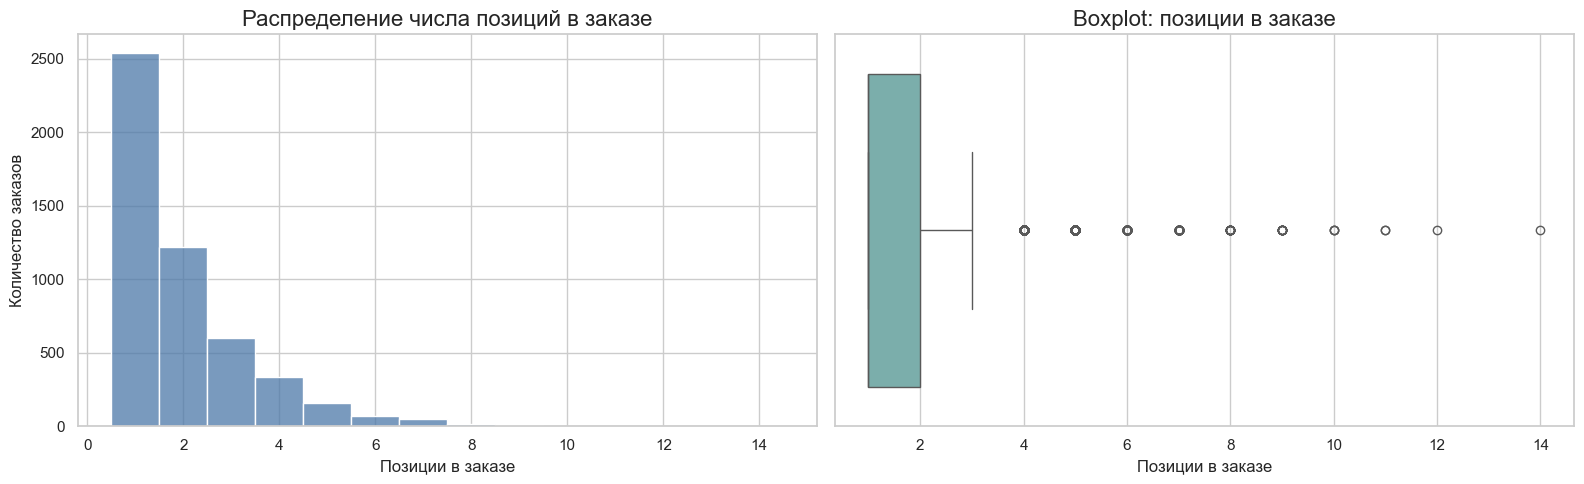


**Вывод по структуре заказов**
- Полных дубликатов нет, а `Row ID` уникален для каждой строки.
- `Order ID` закономерно повторяется: одна транзакция состоит в среднем из **2.00** товарных позиций, медиана равна **1**.
- Максимум в **14** позиций говорит о наличии крупных корзин заказов, что важно для дальнейшей агрегации.


In [18]:
missing_by_column = df.isna().sum().to_frame("missing")
order_lines = df.groupby("Order ID").size().rename("Lines per Order")

quality_summary = pd.DataFrame(
    [
        ("Полные дубликаты строк", int(df.duplicated().sum())),
        ("Уникальность Row ID", df["Row ID"].nunique() == len(df)),
        ("Дубли Order ID", int(df["Order ID"].duplicated().sum())),
        ("Среднее число позиций в заказе", round(order_lines.mean(), 2)),
        ("Медиана позиций в заказе", round(order_lines.median(), 2)),
        ("Максимум позиций в заказе", int(order_lines.max())),
    ],
    columns=["Проверка", "Результат"],
)

id_summary = pd.DataFrame(
    [
        ("Row ID", df["Row ID"].nunique(), "Уникальный идентификатор строки"),
        ("Order ID", df["Order ID"].nunique(), "Заказ может включать несколько строк"),
        ("Customer ID", df["Customer ID"].nunique(), "Повторяется между заказами одного клиента"),
        ("Product ID", df["Product ID"].nunique(), "Один SKU встречается во многих заказах"),
    ],
    columns=["Поле", "nunique", "Комментарий"],
)

display(quality_summary)
display(id_summary)
display(missing_by_column.T)
display(order_lines.describe().to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(order_lines, discrete=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Распределение числа позиций в заказе")
axes[0].set_xlabel("Позиции в заказе")
axes[0].set_ylabel("Количество заказов")

sns.boxplot(x=order_lines, ax=axes[1], color="#72B7B2")
axes[1].set_title("Boxplot: позиции в заказе")
axes[1].set_xlabel("Позиции в заказе")
plt.tight_layout()
plt.show()

print_markdown(
f'''
**Вывод по структуре заказов**
- Полных дубликатов нет, а `Row ID` уникален для каждой строки.
- `Order ID` закономерно повторяется: одна транзакция состоит в среднем из **{order_lines.mean():.2f}** товарных позиций, медиана равна **{order_lines.median():.0f}**.
- Максимум в **{int(order_lines.max())}** позиций говорит о наличии крупных корзин заказов, что важно для дальнейшей агрегации.
'''
)


,count,mean,std,min,q1,median,q3,max
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Delivery Days,"9,994.00",3.96,1.75,0.00,3.00,4.00,5.00,7.00


,Discount,Rows
0,0.00,4798
1,0.10,94
2,0.15,52
3,0.20,3657
4,0.30,227
5,0.32,27
6,0.40,206
7,0.45,11
8,0.50,66
9,0.60,138


,min,max,mean,std,count
Ship Mode,,,,,
Same Day,0,1,0.04,0.21,543
First Class,1,4,2.18,0.77,1538
Second Class,1,5,3.24,1.19,1945
Standard Class,3,7,5.01,1.01,5968


,Discount,Подкатегория
0,0.32,Bookcases
1,0.45,Tables


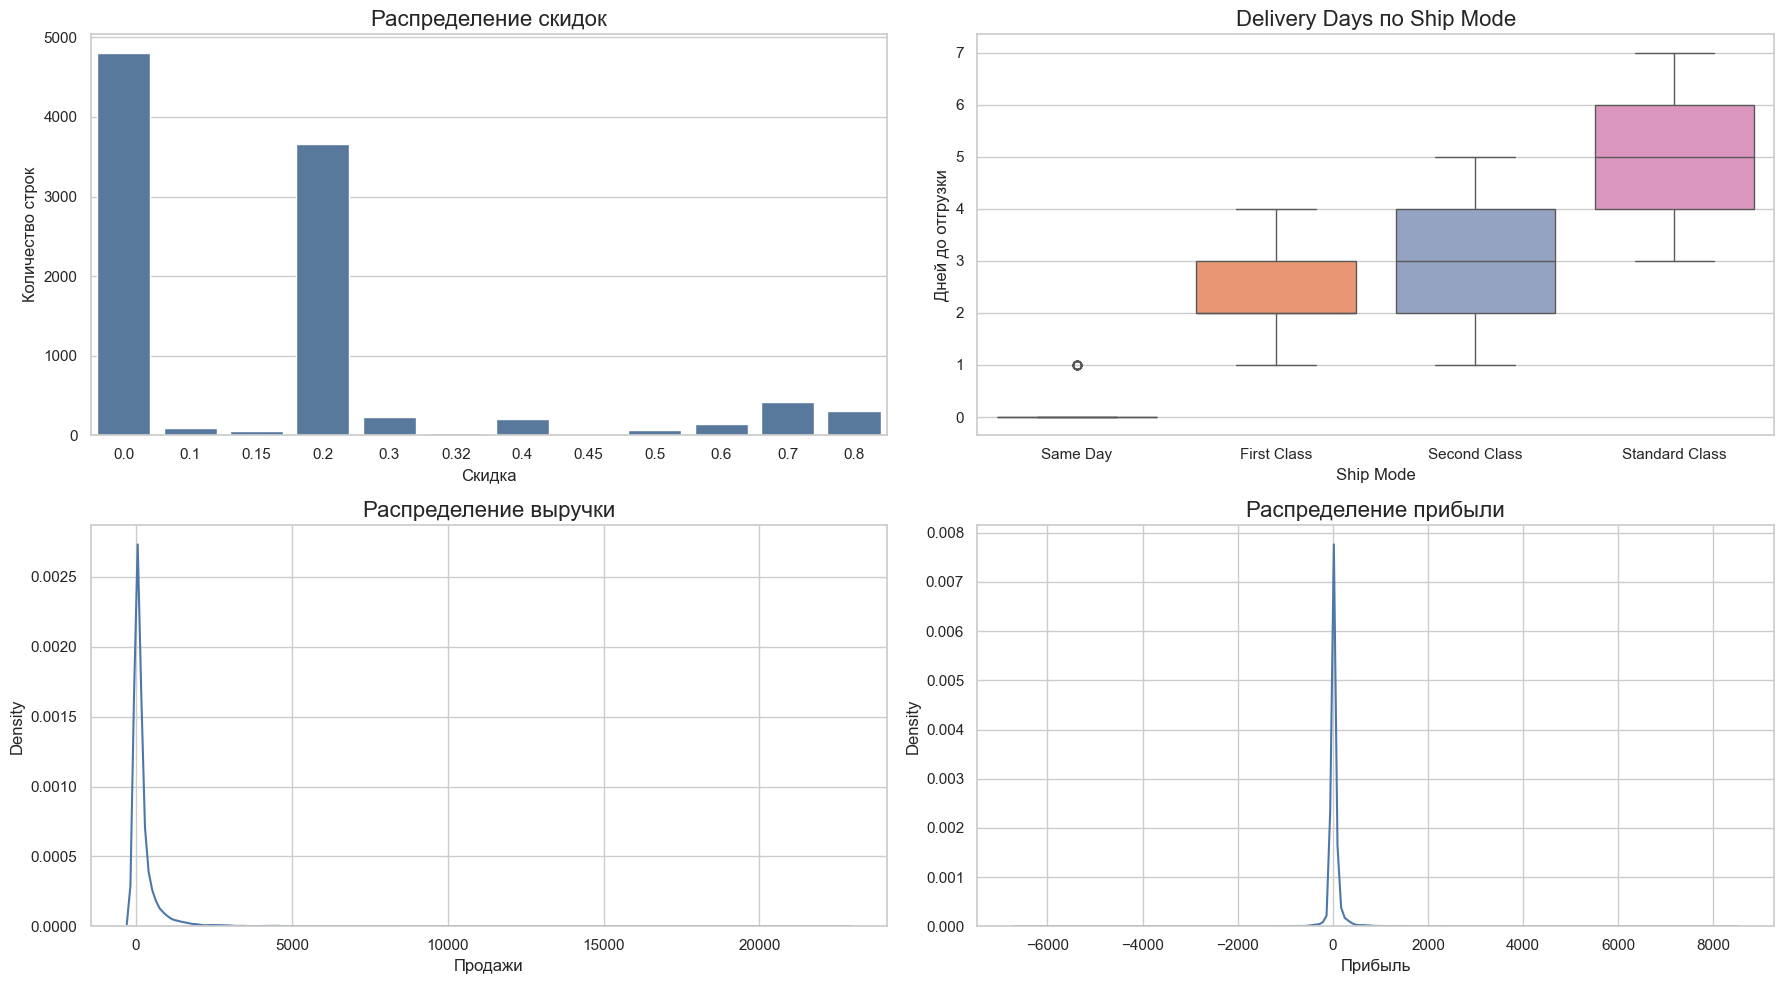


**Ключевые аномалии и выбросы**
- `Sales` и `Profit` имеют длинный правый хвост.
- Отрицательная прибыль встречается в **1871 строках** (18.7%), а ровно нулевая прибыль — в **65 строках**.
- `Discount` является **дискретным** признаком: всего **12 уникальных значений**, причем почти весь объем сосредоточен в точках `0.0` и `0.2`.
- Нестандартные скидки `0.32` и `0.45` жестко привязаны к отдельным подкатегориям, что выглядит как артефакт генерации данных.


In [38]:
numeric_profile = (
    pd.concat(
        {
            column: profile(df[column])
            for column in ["Sales", "Profit", "Quantity", "Discount", "Delivery Days"]
        },
        axis=1,
    )
    .T.round(2)
)

discount_counts = (
    df["Discount"]
    .value_counts()
    .sort_index()
    .rename_axis("Discount")
    .reset_index(name="Rows")
)
delivery_summary = (
    df.groupby("Ship Mode")["Delivery Days"]
    .agg(["min", "max", "mean", "std", "count"])
    .round(2)
    .sort_values("mean")
)
special_discount_mapping = pd.DataFrame(
    [
        (0.32, ", ".join(sorted(df.loc[df["Discount"].eq(0.32), "Sub-Category"].unique()))),
        (0.45, ", ".join(sorted(df.loc[df["Discount"].eq(0.45), "Sub-Category"].unique()))),
    ],
    columns=["Discount", "Подкатегория"],
)

display(numeric_profile)
display(discount_counts)
display(delivery_summary)
display(special_discount_mapping)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.barplot(data=discount_counts, x="Discount", y="Rows", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Распределение скидок")
axes[0, 0].set_xlabel("Скидка")
axes[0, 0].set_ylabel("Количество строк")

ship_order = ["Same Day", "First Class", "Second Class", "Standard Class"]
sns.boxplot(data=df, x="Ship Mode", y="Delivery Days", order=ship_order, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Delivery Days по Ship Mode")
axes[0, 1].set_xlabel("Ship Mode")
axes[0, 1].set_ylabel("Дней до отгрузки")

sns.kdeplot(data=df, x="Sales", ax=axes[1, 0], color="#4C78A8")
axes[1, 0].set_title("Распределение выручки")
axes[1, 0].set_xlabel("Продажи")

sns.kdeplot(data=df, x="Profit", ax=axes[1, 1], color="#4C78A8")
axes[1, 1].set_title("Распределение прибыли")
axes[1, 1].set_xlabel("Прибыль")

plt.tight_layout()
plt.show()

print_markdown(
    f'''
**Ключевые аномалии и выбросы**
- `Sales` и `Profit` имеют длинный правый хвост.
- Отрицательная прибыль встречается в **{df['Is Loss'].sum()} строках** ({percent(df['Is Loss'].mean())}), а ровно нулевая прибыль — в **{int((df['Profit'] == 0).sum())} строках**.
- `Discount` является **дискретным** признаком: всего **{df['Discount'].nunique()} уникальных значений**, причем почти весь объем сосредоточен в точках `0.0` и `0.2`.
- Нестандартные скидки `0.32` и `0.45` жестко привязаны к отдельным подкатегориям, что выглядит как артефакт генерации данных.
'''
)


In [41]:
weekday_counts = df.groupby("Order Weekday", observed=False).size().reindex(df["Order Weekday"].cat.categories)
yearly_rows = df.groupby("Order Year").size()
customer_regions = df.groupby("Customer ID")["Region"].nunique()
customer_states = df.groupby("Customer ID")["State"].nunique()
ship_mode_ranges = (
    df.groupby("Ship Mode")["Delivery Days"]
    .agg(["min", "max", "mean", "std", "nunique"])
    .round(2)
    .sort_values("mean")
)

### Ограничения синтетического датасета и их влияние на моделирование

На этапе EDA были выявлены артефакты синтетической природы датасета. Эти ограничения не делают данные непригодными для анализа, но моогут существенно повлиять на интерпретацию результатов.

1. **Идеально заполненный датасет**
Во всех исходных полях отсутствуют пропуски: в датасете зафиксировано **0 пропусков**.

2. **Заказы без скидки всегда прибыльны**
Среди **4798 строк** со значением `Discount = 0` не обнаружено ни одной убыточной позиции. Такая зависимость выглядит слишком жесткой для реального бизнеса, где даже продажи без скидки могут быть убыточными из-за логистики, возвратов, ошибок в ценообразовании или изменений себестоимости. Следовательно, признак `Discount` в задаче классификации убыточности может стать чрезмерно сильным и сделать модель слишком простой.

3. **Прибыль почти детерминируется скидкой**
Корреляция Спирмена между `Discount` и `Profit` составляет **-0.54**, что указывает на сильную и устойчивую отрицательную связь. Внутри данного датасета скидка фактически выступает главным драйвером прибыльности, тогда как в реальном ритейле на прибыль дополнительно влияют закупочные цены, операционные расходы, возвраты, инфляция и изменения ассортимента. Это ограничивает универсальность будущих выводов по прибыльности.

4. **Клиенты покупают сразу в нескольких регионах**
У **766 из 793 клиентов** зафиксированы покупки в **2 и более регионах**. Для реального ритейла это маловероятно, поскольку большинство клиентов обычно привязаны к одной основной географии доставки или проживания. Следовательно, географические признаки покупателей в этом датасете нельзя считать надежной основой для прогноза.

5. **Аномальное распределение по дням недели**
На среду приходится всего 371 строка, тогда как среднее число строк в остальные дни недели составляет около **1604**. Это скорее просто интересное наблюдение

**Итоговый вывод.**
Датасет подходит для построения аналитических и ML-решений в рамках его внутренней логики, однако модели, обученные на этих данных, следует интерпретировать с учетом синтетических ограничений


## 3. Сквозной анализ продаж

Ниже последовательно рассматриваются ключевые бизнес-срезы: общие KPI, товарные категории, регионы, сегменты клиентов, доставка, временная динамика и уровень заказов.


,Метрика,Значение
0,Общая выручка,"$2,297,200.86"
1,Общая прибыль,"$286,397.02"
2,Маржинальность,12.5%
3,Всего заказов,5009
4,Средняя стоимость заказа,$458.61
5,Среднее число товаров в заказе,2.00


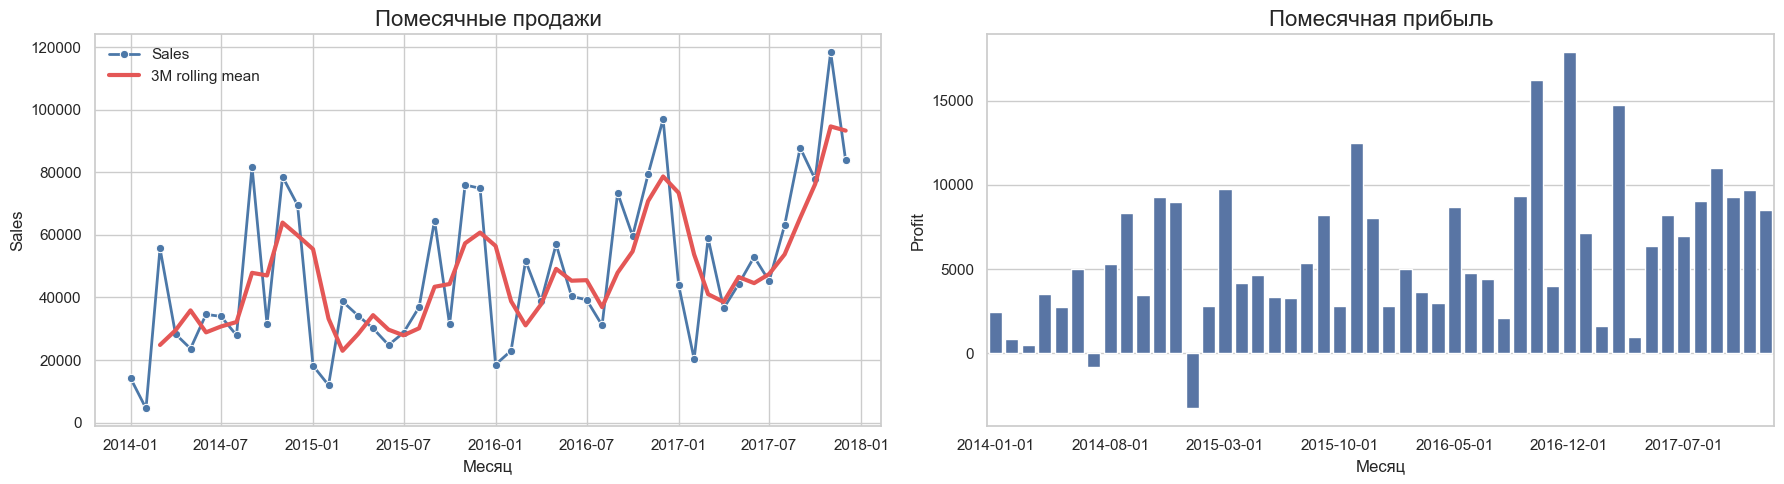

In [59]:
import matplotlib

order_level = df.groupby("Order ID").agg(
    Order_Sales=("Sales", "sum"),
    Order_Profit=("Profit", "sum"),
    Items=("Row ID", "count"),
)
monthly_sales = df.groupby("Order Month Start")["Sales"].sum().sort_index()
monthly_profit = df.groupby("Order Month Start")["Profit"].sum().sort_index()

kpi = pd.DataFrame(
    [
        ("Общая выручка", money(df["Sales"].sum())),
        ("Общая прибыль", money(df["Profit"].sum())),
        ("Маржинальность", percent(df["Profit"].sum() / df["Sales"].sum())),
        ("Всего заказов", df['Order ID'].nunique()),
        ("Средняя стоимость заказа", money(order_level["Order_Sales"].mean())),
        ("Среднее число товаров в заказе", order_level['Items'].mean()),
    ],
    columns=["Метрика", "Значение"],
)

display(kpi)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=monthly_sales, marker="o", linewidth=2, color="#4C78A8", label="Sales", ax=axes[0])
sns.lineplot(data=monthly_sales.rolling(3).mean(), linewidth=3, color="#E45756", label="3M rolling mean", ax=axes[0])
axes[0].set_title("Помесячные продажи")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Sales")
axes[0].legend(frameon=False)

profit_colors = np.where(monthly_profit.values >= 0, "#54A24B", "#E45756")
sns.barplot(monthly_profit, ax=axes[1])
axes[1].xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(7))
axes[1].set_title("Помесячная прибыль")
axes[1].set_xlabel("Месяц")
axes[1].set_ylabel("Profit")
plt.tight_layout()
plt.show()


По временной динамике уже на верхнем уровне виден рост бизнеса к 2017 году и сезонный усиленный спрос в Q4.

,Sales,Profit,Orders,Avg_Discount,Profit_Margin
Category,,,,,
Technology,"836,154.03","145,454.95",1544,0.13,0.17
Furniture,"741,999.80","18,451.27",1764,0.17,0.02
Office Supplies,"719,047.03","122,490.80",3742,0.16,0.17


,Sales,Profit,Quantity,Avg_Discount,Group
Sub-Category,,,,,
Tables,"206,965.53","-17,725.48",1241,0.26,Bottom 5
Bookcases,"114,880.00","-3,472.56",868,0.21,Bottom 5
Supplies,"46,673.54","-1,189.10",647,0.08,Bottom 5
Fasteners,"3,024.28",949.52,914,0.08,Bottom 5
Machines,"189,238.63","3,384.76",440,0.31,Bottom 5
Copiers,"149,528.03","55,617.82",234,0.16,Top 5
Phones,"330,007.05","44,515.73",3289,0.15,Top 5
Accessories,"167,380.32","41,936.64",2976,0.08,Top 5
Paper,"78,479.21","34,053.57",5178,0.07,Top 5


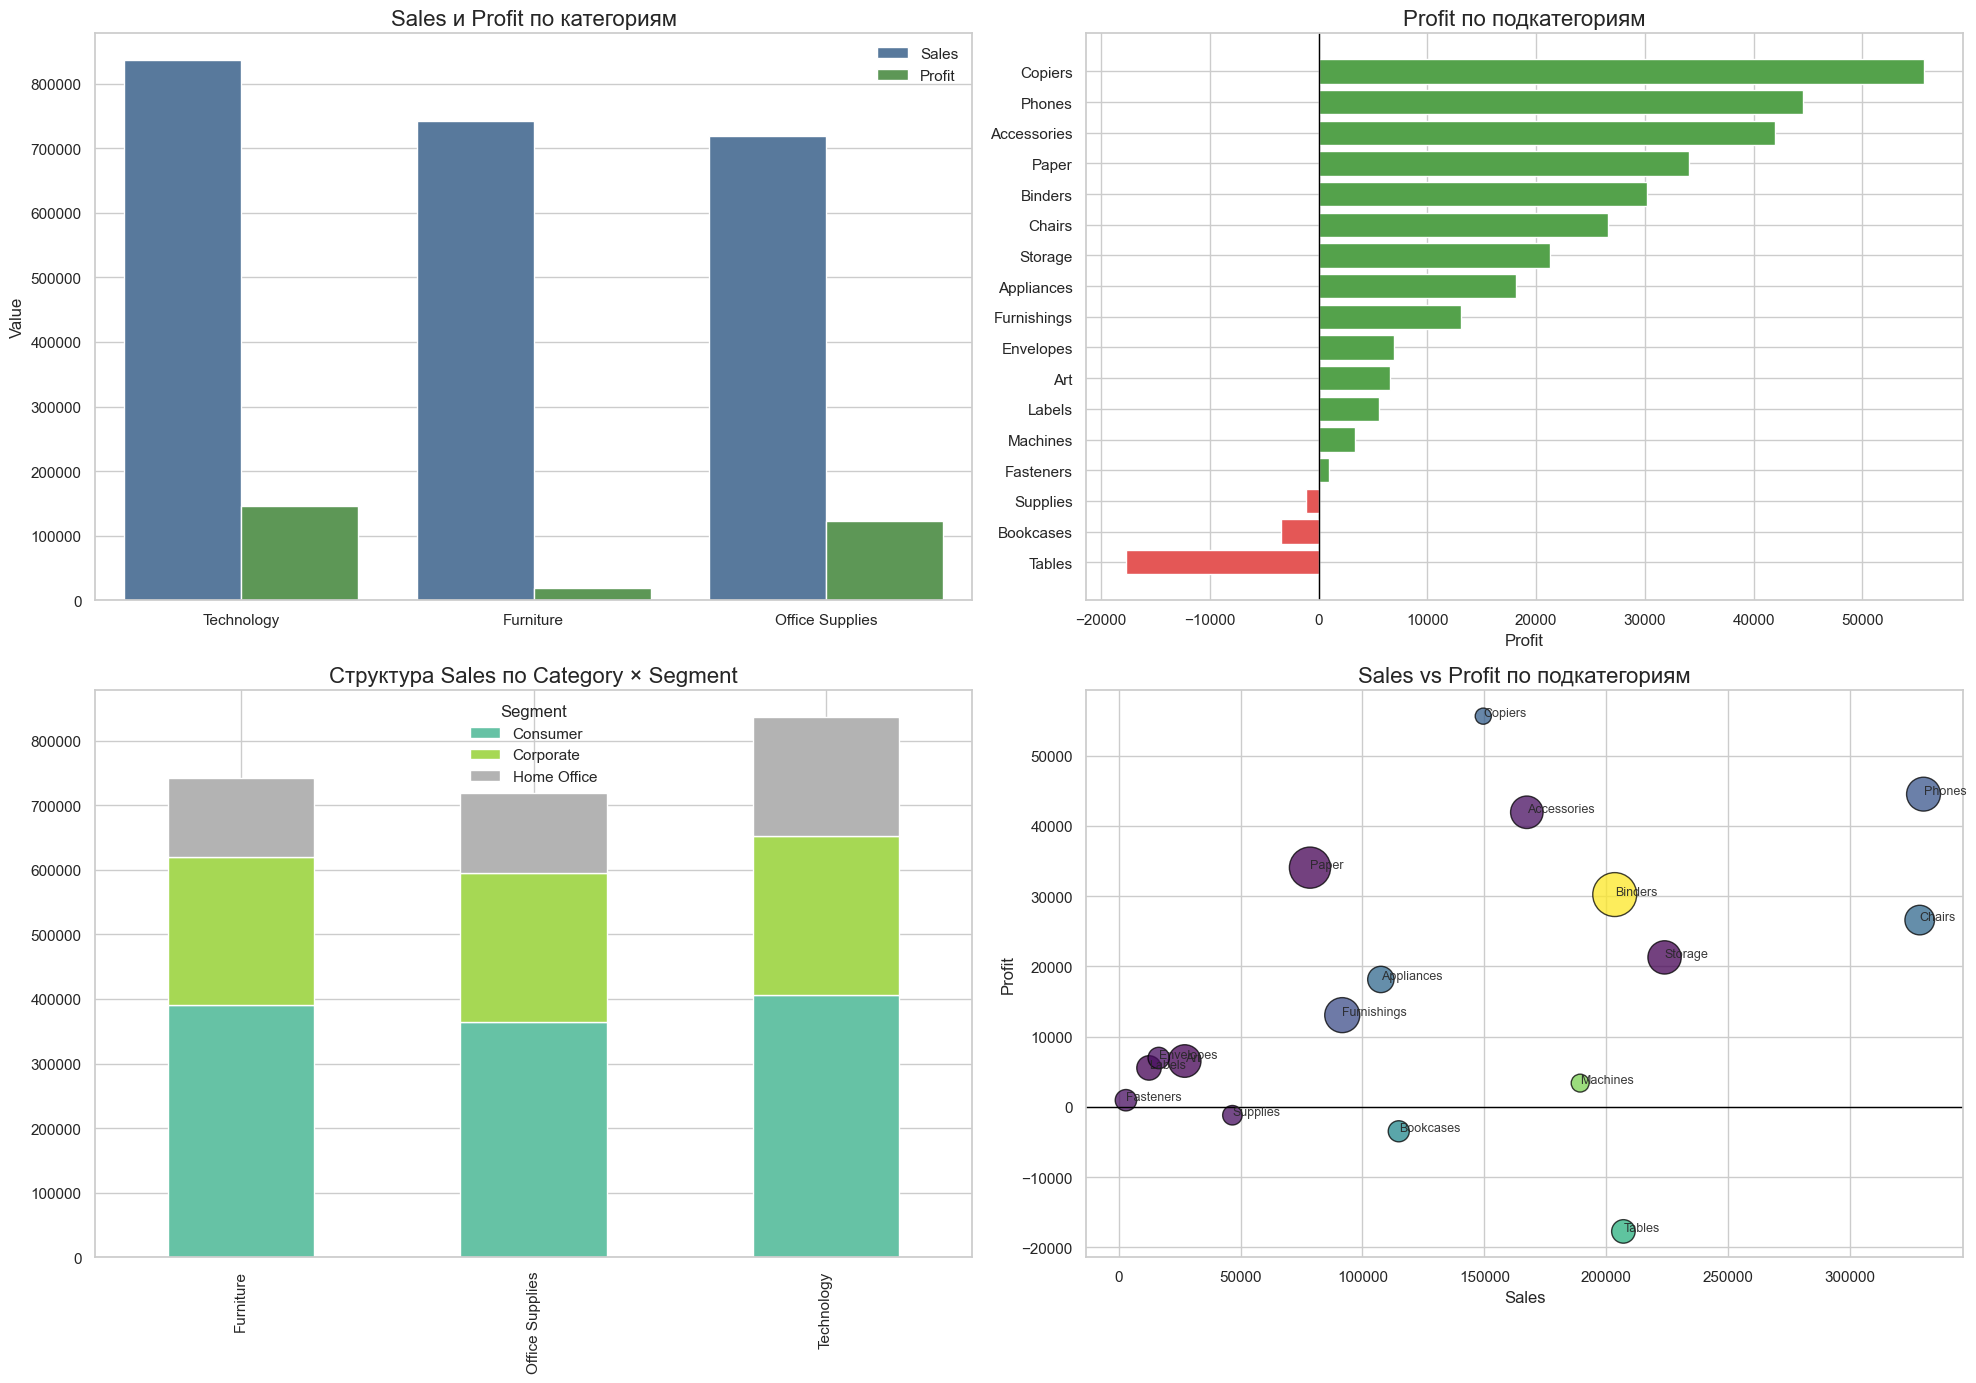


**Выводы по категориям**
- По выручке лидирует **Technology**,  наибольшую прибыль генерирует **Technology**.
- Самая проблемная подкатегория по абсолютной прибыли — **Tables** (-17725.48).
- Наиболее прибыльная подкатегория — **Copiers** (55617.82), хотя по числу строк она не является крупнейшей.
- Уже на этом шаге видно, что выручка и прибыль не совпадают по лидерам, значит для бизнеса критична не только динамика продаж, но и структура маржинальности.


In [61]:
category_summary = (
    df.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean"),
    )
    .assign(Profit_Margin=lambda table: table["Profit"] / table["Sales"])
    .sort_values("Sales", ascending=False)
    .round(2)
)

subcategory_summary = (
    df.groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Avg_Discount=("Discount", "mean"),
    )
    .sort_values("Profit")
    .round(2)
)
category_segment_sales = pd.pivot_table(
    df,
    index="Category",
    columns="Segment",
    values="Sales",
    aggfunc="sum",
).fillna(0)

display(category_summary)
display(
    pd.concat(
        [
            subcategory_summary.head(5).assign(Group="Bottom 5"),
            subcategory_summary.tail(5).sort_values("Profit", ascending=False).assign(Group="Top 5"),
        ]
    )
)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

category_plot = category_summary.reset_index().melt(
    id_vars="Category",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Value",
)
sns.barplot(data=category_plot, x="Category", y="Value", hue="Metric", ax=axes[0, 0], palette=["#4C78A8", "#54A24B"])
axes[0, 0].set_title("Sales и Profit по категориям")
axes[0, 0].set_xlabel("")
axes[0, 0].legend(frameon=False)

profit_colors = np.where(subcategory_summary["Profit"] >= 0, "#54A24B", "#E45756")
axes[0, 1].barh(subcategory_summary.index, subcategory_summary["Profit"], color=profit_colors)
axes[0, 1].axvline(0, color="black", linewidth=1)
axes[0, 1].set_title("Profit по подкатегориям")
axes[0, 1].set_xlabel("Profit")
axes[0, 1].set_ylabel("")

category_segment_sales.plot(kind="bar", stacked=True, ax=axes[1, 0], colormap="Set2")
axes[1, 0].set_title("Структура Sales по Category × Segment")
axes[1, 0].set_xlabel("")
axes[1, 0].legend(title="Segment", frameon=False)

scatter_sizes = 100 + 900 * (subcategory_summary["Quantity"] / subcategory_summary["Quantity"].max())
axes[1, 1].scatter(
    subcategory_summary["Sales"],
    subcategory_summary["Profit"],
    s=scatter_sizes,
    c=subcategory_summary["Avg_Discount"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
)
for name, row in subcategory_summary.iterrows():
    axes[1, 1].annotate(name, (row["Sales"], row["Profit"]), fontsize=9, alpha=0.9)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Sales vs Profit по подкатегориям")
axes[1, 1].set_xlabel("Sales")
axes[1, 1].set_ylabel("Profit")
plt.tight_layout()
plt.show()

worst_subcat = subcategory_summary.index[0]
best_subcat = subcategory_summary.sort_values("Profit", ascending=False).index[0]

print_markdown(
f'''
**Выводы по категориям**
- По выручке лидирует **{category_summary.index[0]}**,  наибольшую прибыль генерирует **{category_summary['Profit'].idxmax()}**.
- Самая проблемная подкатегория по абсолютной прибыли — **{worst_subcat}** ({subcategory_summary.iloc[0]['Profit']}).
- Наиболее прибыльная подкатегория — **{best_subcat}** ({subcategory_summary.sort_values('Profit', ascending=False).iloc[0]['Profit']}), хотя по объемам она не является крупнейшей.
- Уже на этом шаге видно, что выручка и прибыль не совпадают по лидерам, значит для бизнеса критична не только динамика продаж, но и структура маржинальности.
'''
)


,Sales,Profit,Avg_Discount,Orders,Profit_Margin
Region,,,,,
Central,"501,239.89","39,706.36",0.24,1175,0.08
South,"391,721.90","46,749.43",0.15,822,0.12
East,"678,781.24","91,522.78",0.15,1401,0.13
West,"725,457.82","108,418.45",0.11,1611,0.15


,Bottom 10 states by Profit
State,
Texas,"-25,729.36"
Ohio,"-16,971.38"
Pennsylvania,"-15,559.96"
Illinois,"-12,607.89"
North Carolina,"-7,490.91"
Colorado,"-6,527.86"
Tennessee,"-5,341.69"
Arizona,"-3,427.92"
Florida,"-3,399.30"


,Top 10 states by Profit
State,
California,"76,381.39"
New York,"74,038.55"
Washington,"33,402.65"
Michigan,"24,463.19"
Virginia,"18,597.95"
Indiana,"18,382.94"
Georgia,"16,250.04"
Kentucky,"11,199.70"
Minnesota,"10,823.19"


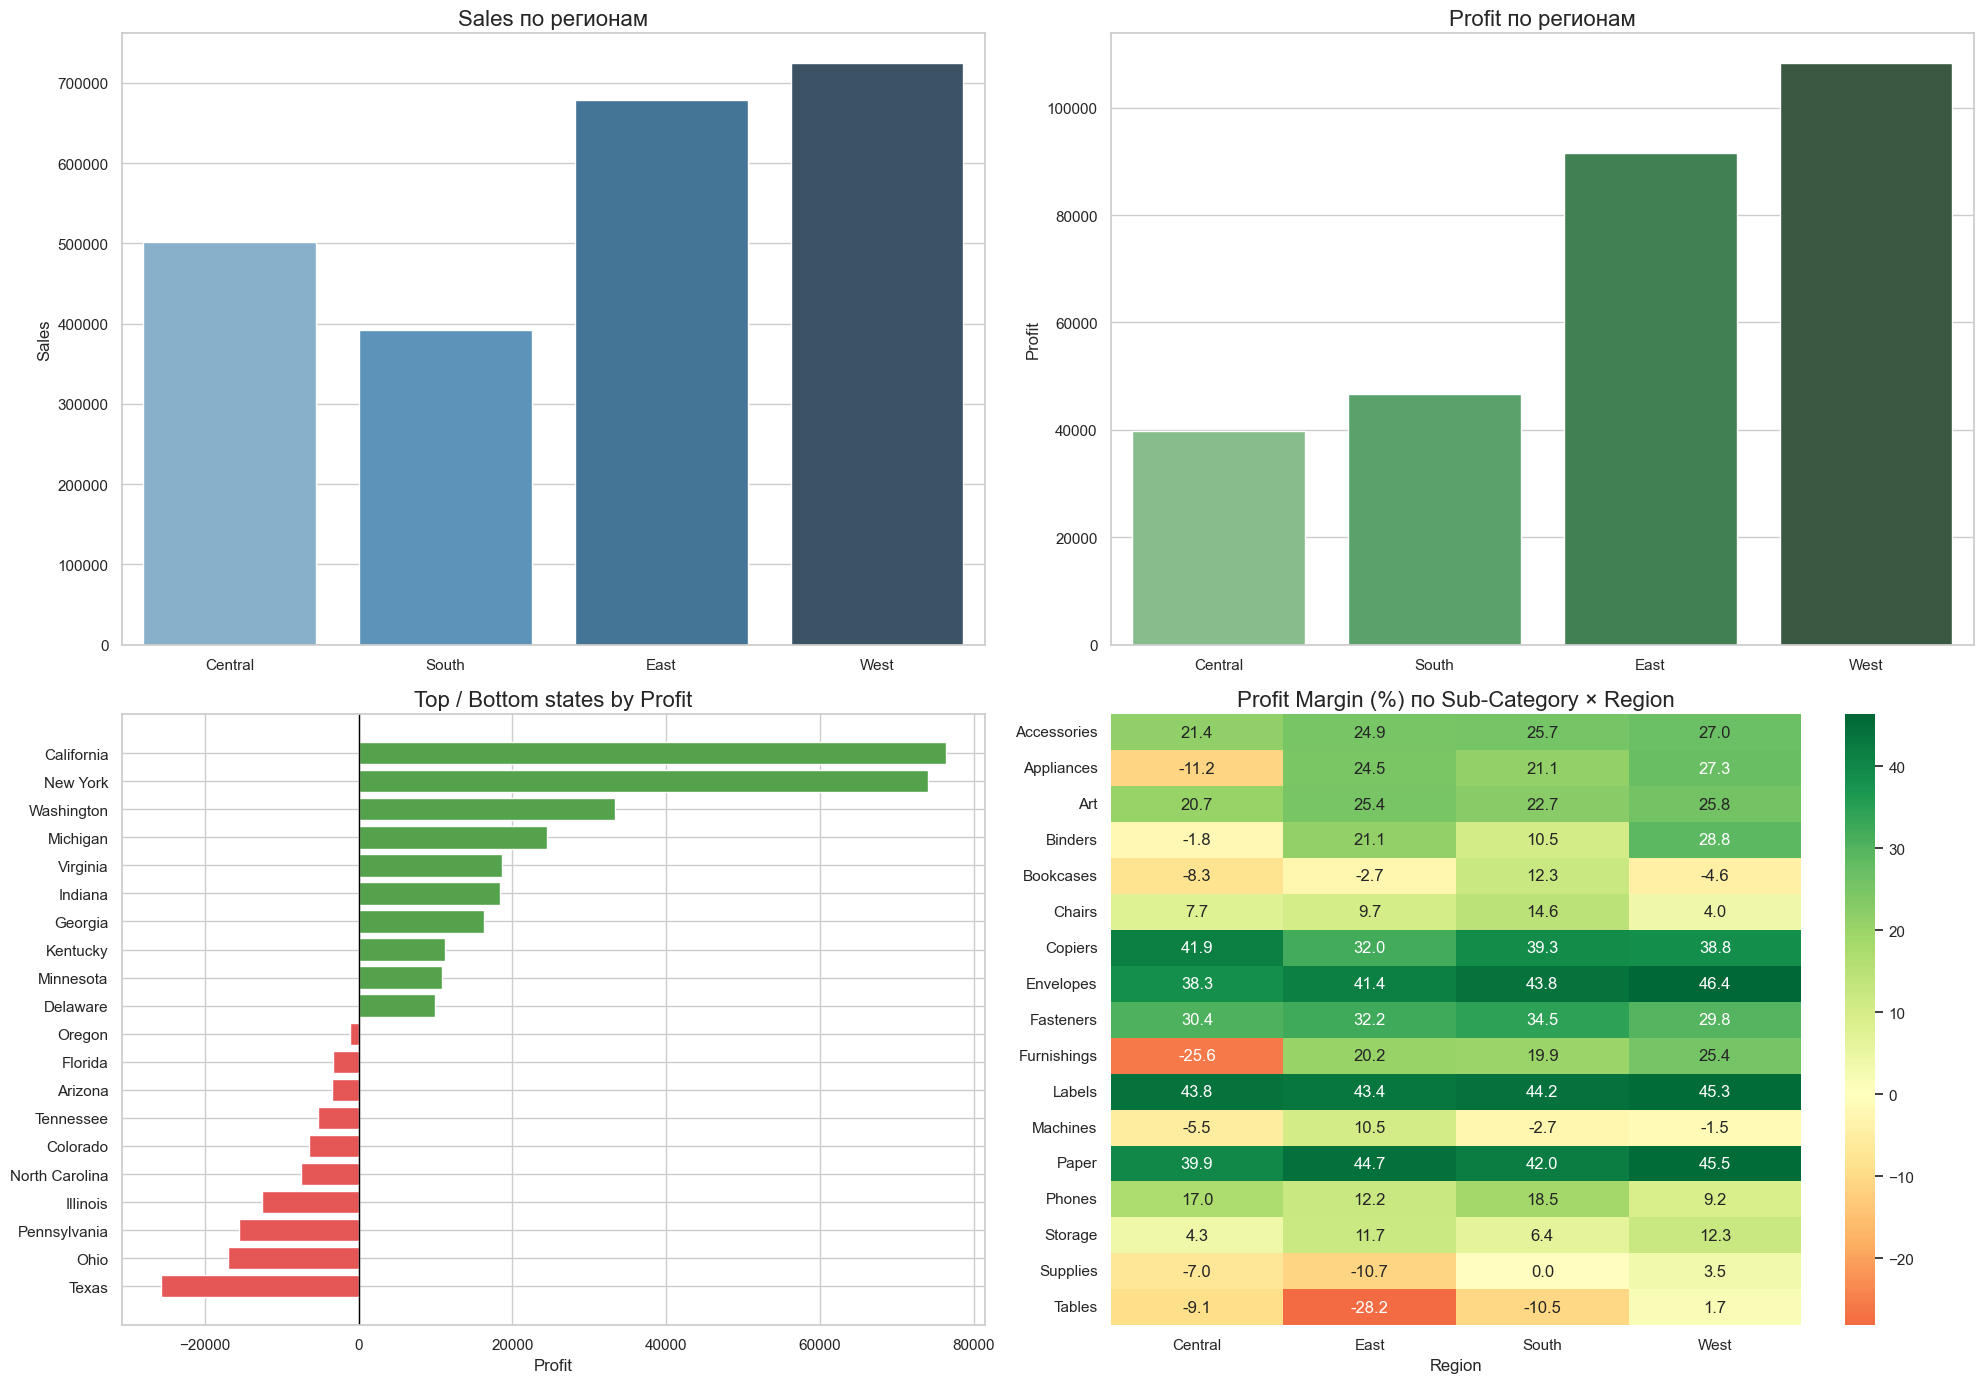


**Региональные инсайты**
- Регион **Central** демонстрирует минимальную прибыль (**$39,706.36**) при самой высокой средней скидке (**24.0%**).
- Лучший результат по прибыли показывает **West**, что подтверждает наличие региональных различий не только по объему, но и по качеству продаж.
- Тепловая карта показывает, что убыточность концентрируется неравномерно: проблемные подкатегории остаются проблемными, но их глубина просадки меняется от региона к региону.


In [62]:
region_summary = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean"),
        Orders=("Order ID", "nunique"),
    )
    .assign(Profit_Margin=lambda table: table["Profit"] / table["Sales"])
    .sort_values("Profit")
    .round(2)
)
state_profit = df.groupby("State")["Profit"].sum().sort_values()
region_margin_matrix = (
    df.groupby(["Sub-Category", "Region"])
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .assign(Profit_Margin=lambda table: 100 * table["Profit"] / table["Sales"])
    .reset_index()
    .pivot(index="Sub-Category", columns="Region", values="Profit_Margin")
)

display(region_summary)
display(state_profit.head(10).to_frame("Bottom 10 states by Profit"))
display(state_profit.tail(10).sort_values(ascending=False).to_frame("Top 10 states by Profit"))

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.barplot(
    x=region_summary.index,
    y=region_summary["Sales"],
    ax=axes[0, 0],
    palette="Blues_d",
)
axes[0, 0].set_title("Sales по регионам")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Sales")

sns.barplot(
    x=region_summary.index,
    y=region_summary["Profit"],
    ax=axes[0, 1],
    palette="Greens_d",
)
axes[0, 1].set_title("Profit по регионам")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Profit")

state_slice = pd.concat([state_profit.head(10), state_profit.tail(10)]).sort_values()
state_colors = np.where(state_slice >= 0, "#54A24B", "#E45756")
axes[1, 0].barh(state_slice.index, state_slice.values, color=state_colors)
axes[1, 0].axvline(0, color="black", linewidth=1)
axes[1, 0].set_title("Top / Bottom states by Profit")
axes[1, 0].set_xlabel("Profit")
axes[1, 0].set_ylabel("")

sns.heatmap(region_margin_matrix, cmap="RdYlGn", center=0, annot=True, fmt=".1f", ax=axes[1, 1])
axes[1, 1].set_title("Profit Margin (%) по Sub-Category × Region")
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("")
plt.tight_layout()
plt.show()

print_markdown(
f'''
**Региональные инсайты**
- Регион **{region_summary.index[0]}** демонстрирует минимальную прибыль (**{region_summary.iloc[0]['Profit']}**) при самой высокой средней скидке (**{percent(region_summary.iloc[0]['Avg_Discount'])}**).
- Лучший результат по прибыли показывает **{region_summary['Profit'].idxmax()}**, что подтверждает наличие региональных различий не только по объему, но и по качеству продаж.
- Тепловая карта показывает, что убыточность концентрируется неравномерно: проблемные подкатегории остаются проблемными, но их глубина просадки меняется от региона к региону.
'''
)

,Sales,Profit,Orders,Profit_Margin
Segment,,,,
Consumer,"1,161,401.34","134,119.21",2586,0.12
Corporate,"706,146.37","91,979.13",1514,0.13
Home Office,"429,653.15","60,298.68",909,0.14


,Sales,Profit,Avg_Delivery,Orders,Profit_Margin
Ship Mode,,,,,
Standard Class,"1,358,215.74","164,088.79",5.01,2994,0.12
Second Class,"459,193.57","57,446.64",3.24,964,0.13
First Class,"351,428.42","48,969.84",2.18,787,0.14
Same Day,"128,363.12","15,891.76",0.04,264,0.12


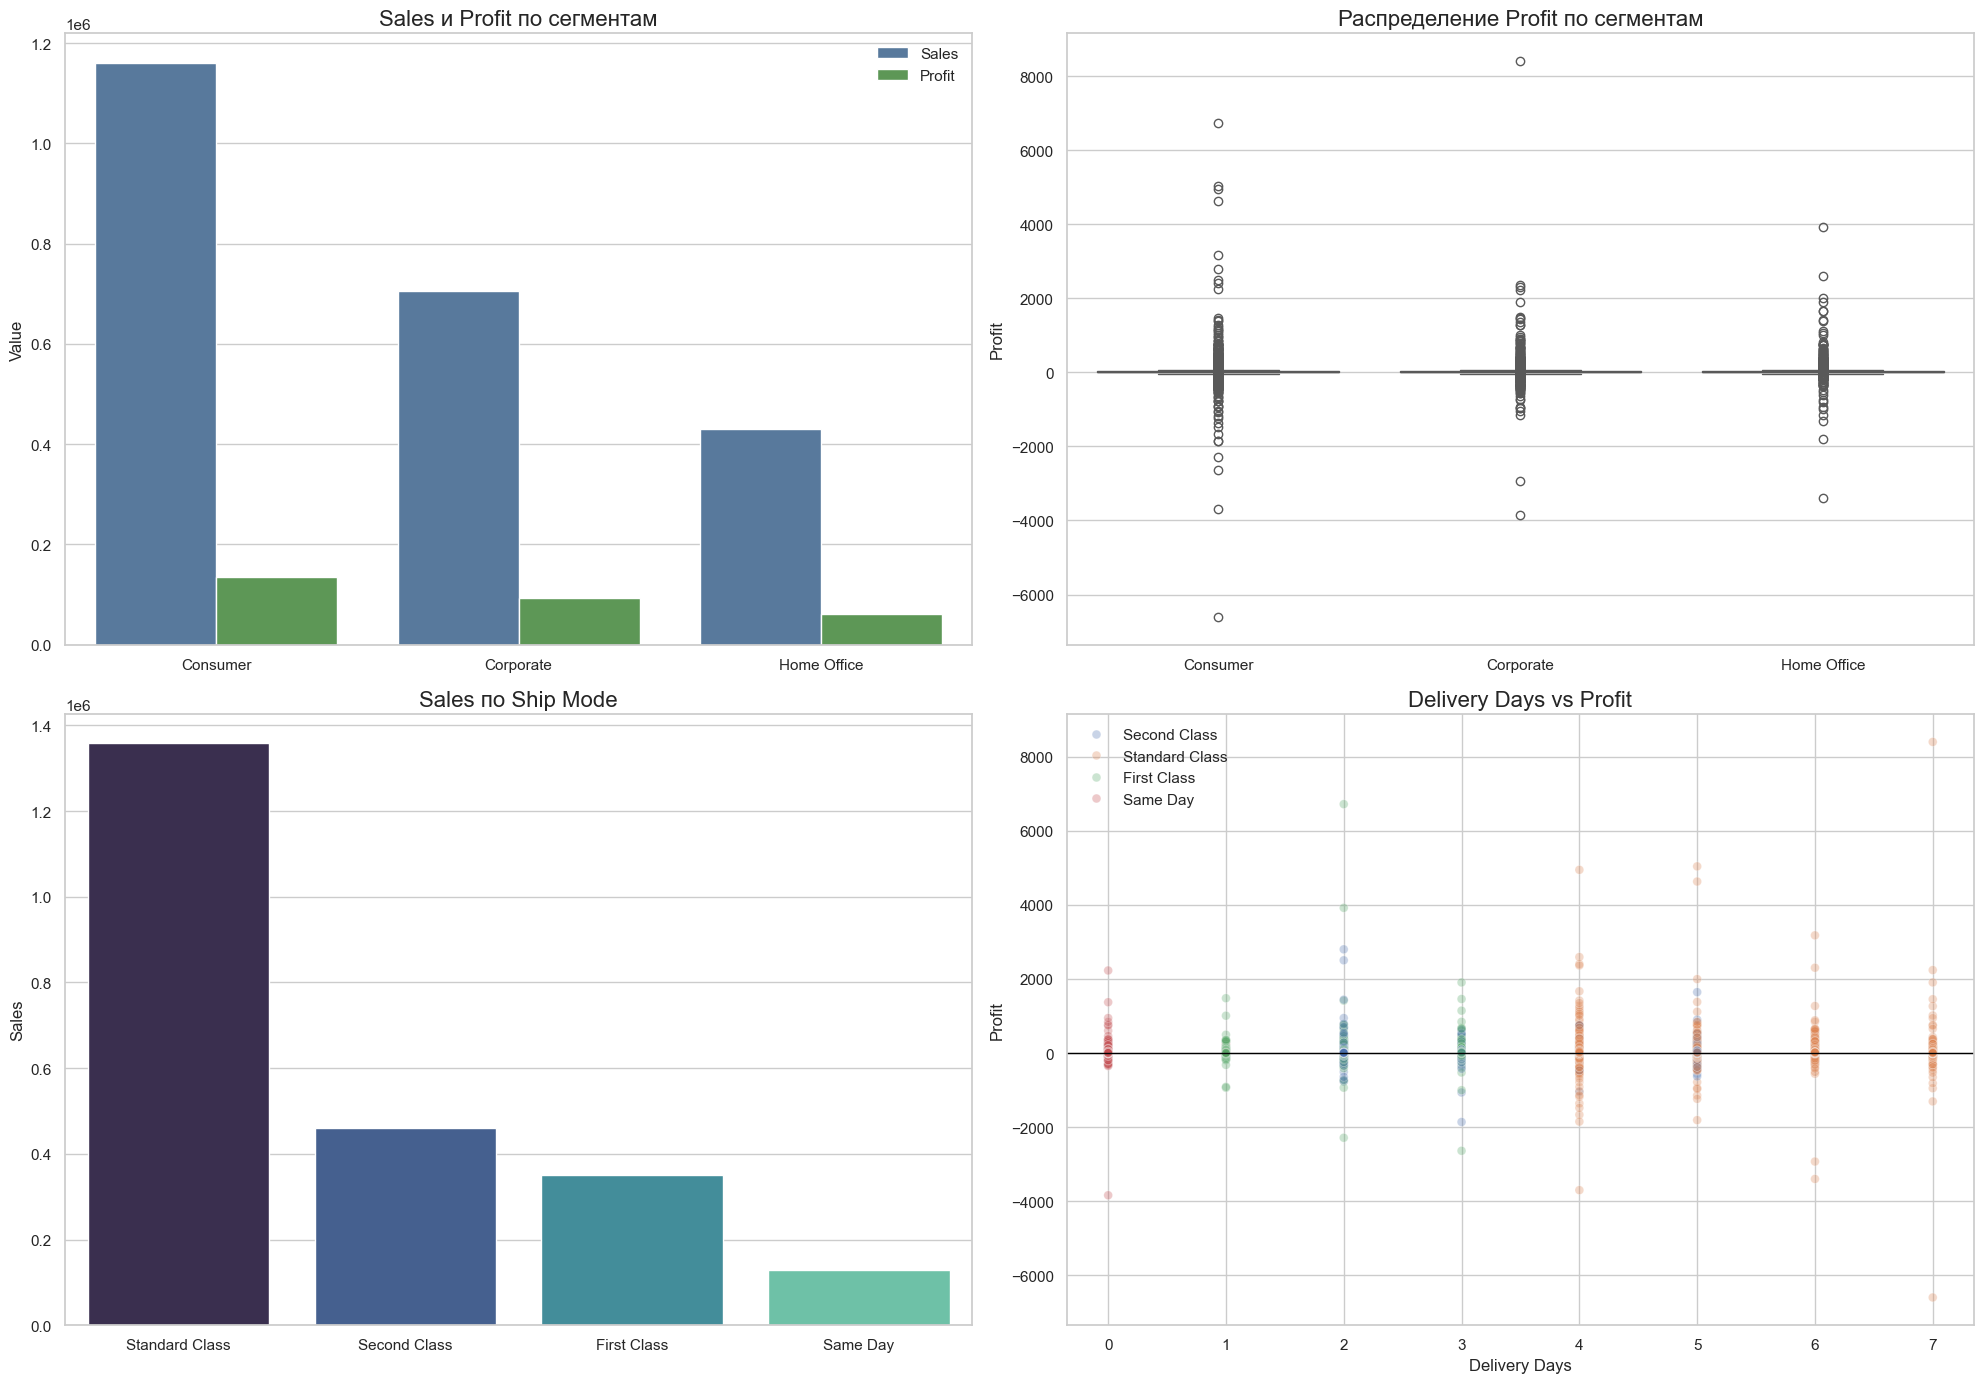


**Сегменты и доставка**
- Сегмент **Consumer** формирует наибольший объем продаж, но максимальная маржа наблюдается у **Home Office**.
- В доставке доминирует **Standard Class**, что важно учитывать для операционного baseline и сценариев масштабирования.
- Связь между `Delivery Days` и `Profit` слабая: логистический сигнал в этих данных значительно слабее скидочного и товарного.


In [63]:
segment_summary = (
    df.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
    )
    .assign(Profit_Margin=lambda table: table["Profit"] / table["Sales"])
    .sort_values("Sales", ascending=False)
    .round(2)
)

ship_mode_summary = (
    df.groupby("Ship Mode")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Delivery=("Delivery Days", "mean"),
        Orders=("Order ID", "nunique"),
    )
    .assign(Profit_Margin=lambda table: table["Profit"] / table["Sales"])
    .sort_values("Sales", ascending=False)
    .round(2)
)

display(segment_summary)
display(ship_mode_summary)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

segment_plot = segment_summary.reset_index().melt(
    id_vars="Segment",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Value",
)
sns.barplot(data=segment_plot, x="Segment", y="Value", hue="Metric", ax=axes[0, 0], palette=["#4C78A8", "#54A24B"])
axes[0, 0].set_title("Sales и Profit по сегментам")
axes[0, 0].set_xlabel("")
axes[0, 0].legend(frameon=False)

sns.boxplot(data=df, x="Segment", y="Profit", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Распределение Profit по сегментам")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Profit")

sns.barplot(
    x=ship_mode_summary.index,
    y=ship_mode_summary["Sales"],
    ax=axes[1, 0],
    palette="mako",
)
axes[1, 0].set_title("Sales по Ship Mode")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Sales")

sns.scatterplot(
    data=df,
    x="Delivery Days",
    y="Profit",
    hue="Ship Mode",
    alpha=0.30,
    s=40,
    ax=axes[1, 1],
)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Delivery Days vs Profit")
axes[1, 1].set_xlabel("Delivery Days")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].legend(frameon=False)
plt.tight_layout()
plt.show()

print_markdown(
    f'''
**Сегменты и доставка**
- Сегмент **{segment_summary.index[0]}** формирует наибольший объем продаж, но максимальная маржа наблюдается у **{segment_summary['Profit_Margin'].idxmax()}**.
- В доставке доминирует **{ship_mode_summary.index[0]}**.
- Связь между `Delivery Days` и `Profit` слабая: логистический сигнал в этих данных значительно слабее скидочного и товарного.
'''
)


## 4. Временной анализ и уровень заказов

Для задачи прогнозирования важно понять наличие тренда, сезонности и характер временной нестабильности, а для бизнес-интерпретации — структуру самих заказов.


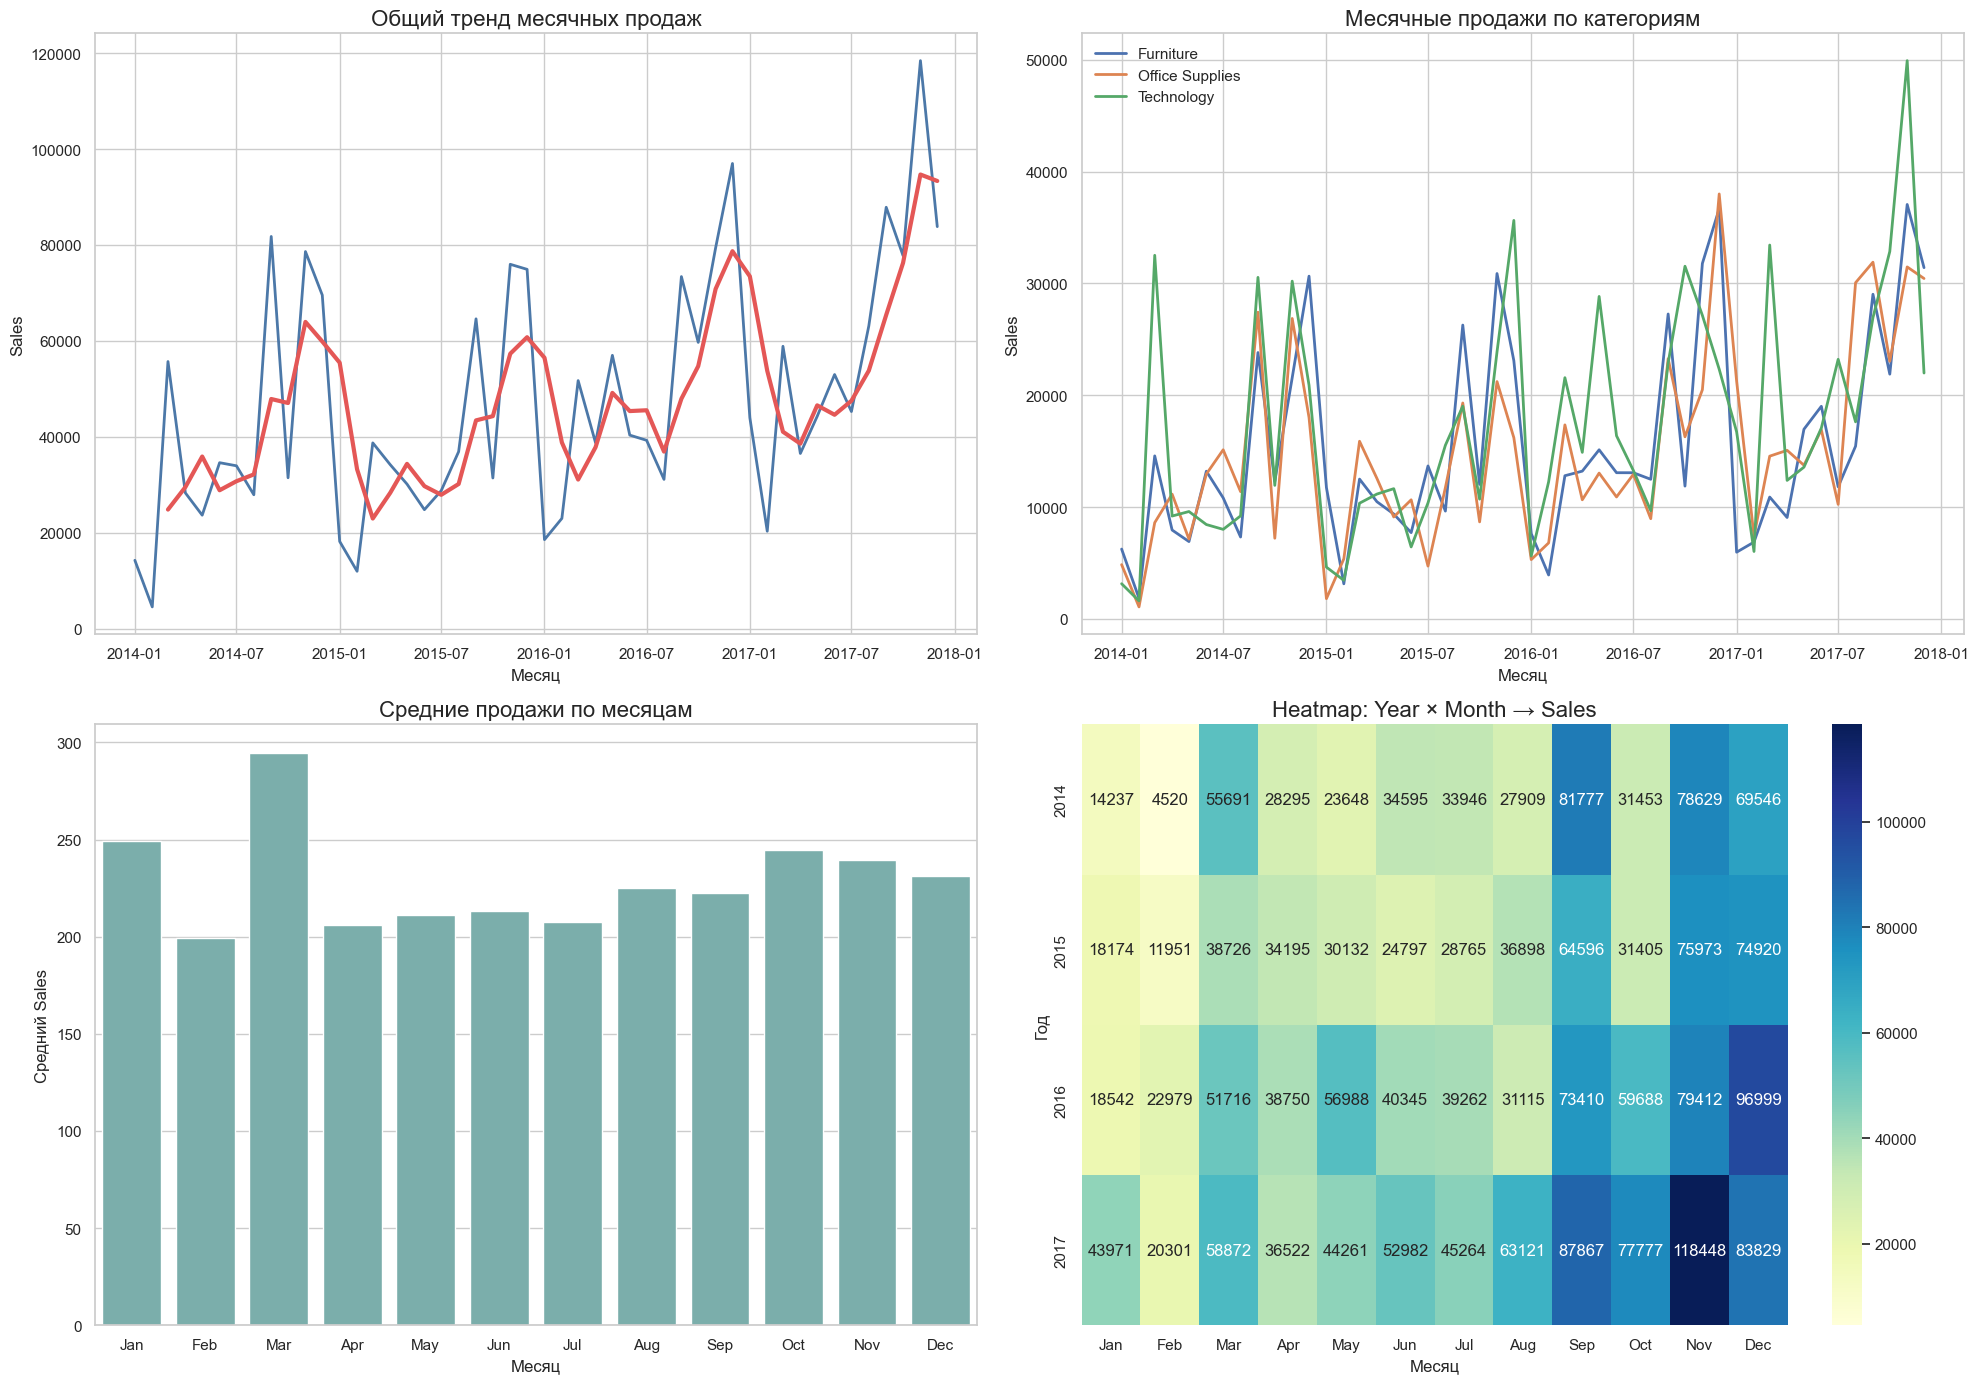

,Тест,p-value,Интерпретация
0,ADF,0.00,ряд стационарен
1,KPSS,0.02,ряд нестационарен



**Временные выводы**
- Продажи демонстрируют выраженный ап-тренд к 2017 году и сезонные пики в конце года.
- Тесты стационарности дают смешанный сигнал: `ADF p-value = 0.0002`, `KPSS p-value = 0.0187`. Это типично для ряда с трендом и сезонностью.
- Для моделирования продаж нужны лаговые признаки, календарные признаки и отдельная работа с нестационарностью; простой константный baseline будет слабым.


In [64]:
monthly_sales_by_category = pd.pivot_table(
    df,
    index="Order Month Start",
    columns="Category",
    values="Sales",
    aggfunc="sum",
).fillna(0)

average_sales_by_month = (
    df.groupby("Order Month Name", observed=False)["Sales"]
    .mean()
    .reindex(df["Order Month Name"].cat.categories)
)

year_month_heatmap = pd.pivot_table(
    df,
    index="Order Year",
    columns="Order Month Name",
    values="Sales",
    aggfunc="sum",
).reindex(columns=df["Order Month Name"].cat.categories)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

axes[0, 0].plot(monthly_sales.index, monthly_sales.values, color="#4C78A8", linewidth=2)
axes[0, 0].plot(monthly_sales.index, monthly_sales.rolling(3).mean(), color="#E45756", linewidth=3)
axes[0, 0].set_title("Общий тренд месячных продаж")
axes[0, 0].set_xlabel("Месяц")
axes[0, 0].set_ylabel("Sales")

for category in monthly_sales_by_category.columns:
    axes[0, 1].plot(
        monthly_sales_by_category.index,
        monthly_sales_by_category[category],
        linewidth=2,
        label=category,
    )
axes[0, 1].set_title("Месячные продажи по категориям")
axes[0, 1].set_xlabel("Месяц")
axes[0, 1].set_ylabel("Sales")
axes[0, 1].legend(frameon=False)

sns.barplot(
    x=average_sales_by_month.index,
    y=average_sales_by_month.values,
    ax=axes[1, 0],
    color="#72B7B2",
)
axes[1, 0].set_title("Средние продажи по месяцам")
axes[1, 0].set_xlabel("Месяц")
axes[1, 0].set_ylabel("Средний Sales")

sns.heatmap(year_month_heatmap, cmap="YlGnBu", annot=True, fmt=".0f", ax=axes[1, 1])
axes[1, 1].set_title("Heatmap: Year × Month → Sales")
axes[1, 1].set_xlabel("Месяц")
axes[1, 1].set_ylabel("Год")
plt.tight_layout()
plt.show()

adf_pvalue = adfuller(monthly_sales)[1]
kpss_pvalue = kpss(monthly_sales, regression="c", nlags="auto")[1]
stationarity = pd.DataFrame(
    [
        ("ADF", adf_pvalue, "ряд стационарен" if adf_pvalue < 0.05 else "ряд нестационарен"),
        ("KPSS", kpss_pvalue, "ряд стационарен" if kpss_pvalue > 0.05 else "ряд нестационарен"),
    ],
    columns=["Тест", "p-value", "Интерпретация"],
)

display(stationarity)

print_markdown(
f'''
**Временные выводы**
- Продажи демонстрируют выраженный ап-тренд к 2017 году и сезонные пики в конце года.
- Тесты стационарности дают смешанный сигнал: `ADF p-value = {adf_pvalue:.4f}`, `KPSS p-value = {kpss_pvalue:.4f}`. Это типично для ряда с трендом и сезонностью.
- Для моделирования продаж нужны лаговые признаки, календарные признаки и отдельная работа с нестационарностью; простой константный baseline будет слабым.
'''
)


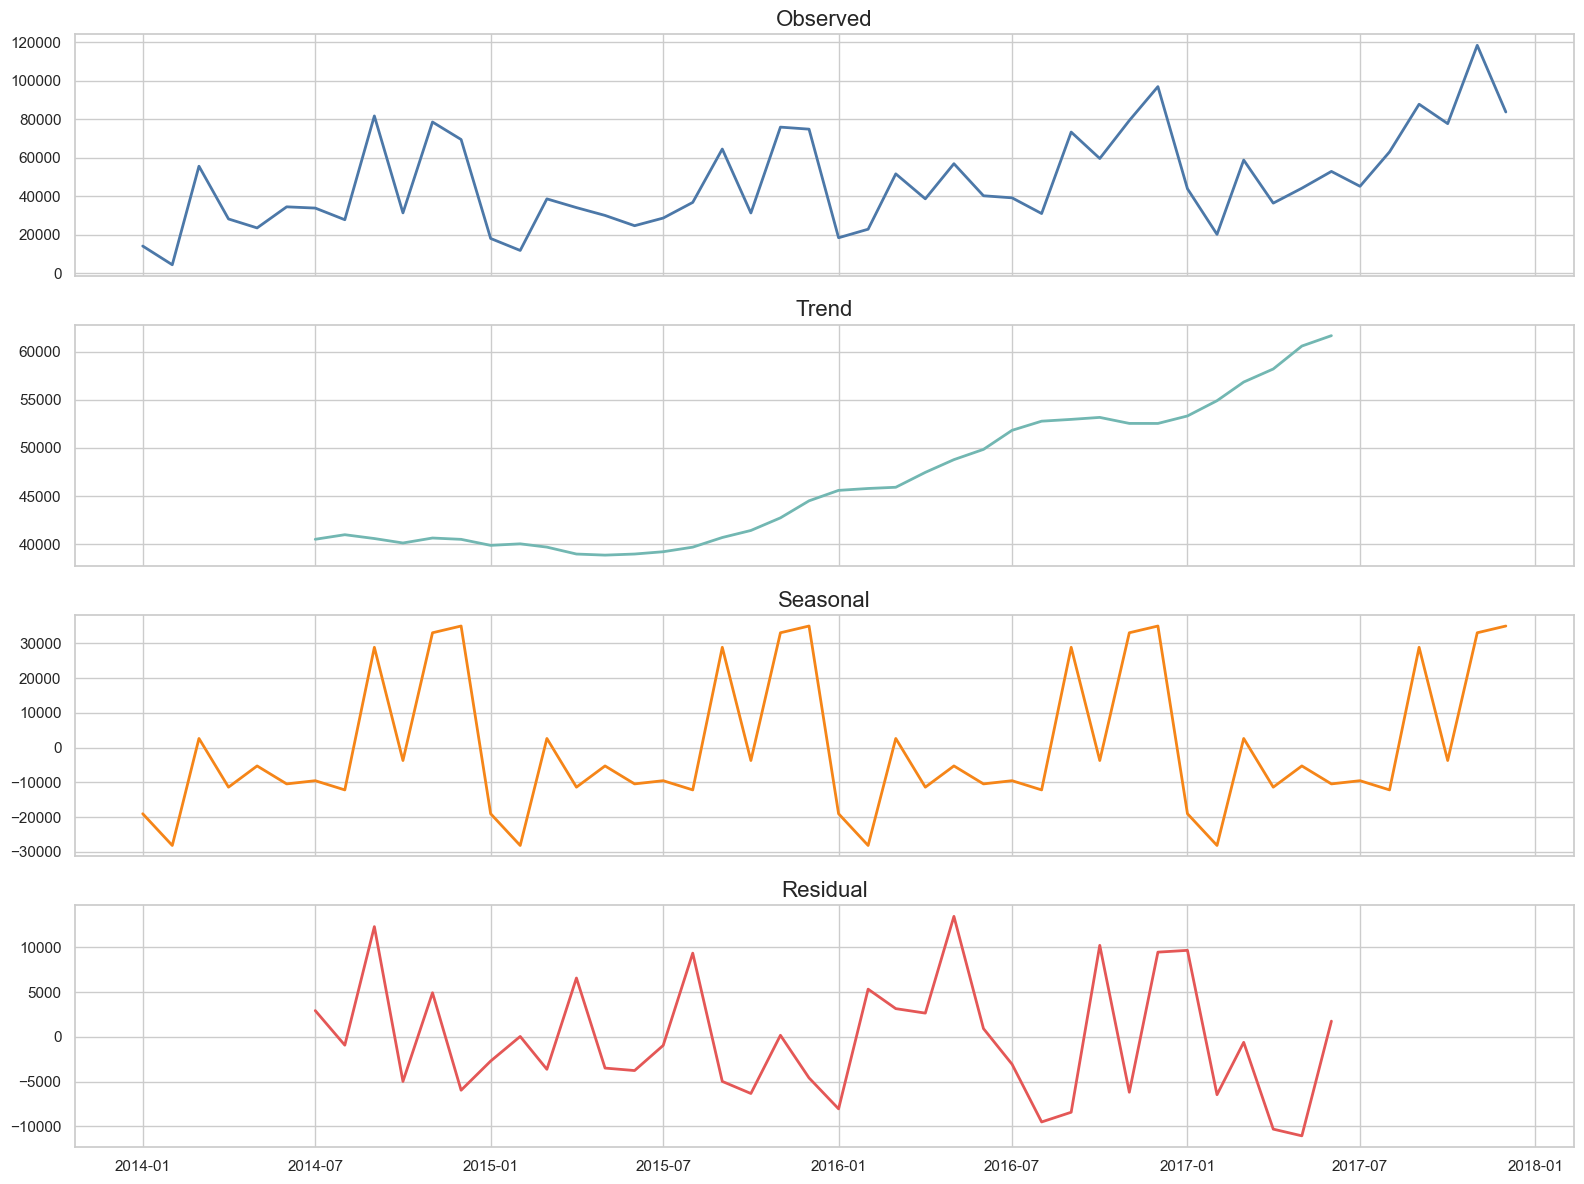

,count,mean,std,min,25%,50%,75%,max
Order_Sales,"5,009.00",458.61,954.73,0.56,37.63,151.96,512.06,"23,661.23"
Order_Profit,"5,009.00",57.18,344.94,"-6,892.37",2.05,16.28,68.69,"8,762.39"
Order_Quantity,"5,009.00",7.56,6.22,1.00,3.00,6.00,10.00,52.00
Items,"5,009.00",2.00,1.41,1.00,1.00,1.00,2.00,14.00
Categories,"5,009.00",1.41,0.61,1.00,1.00,1.00,2.00,3.00


,share
Categories,
1 category,0.66
2 categories,0.28
3 categories,0.06


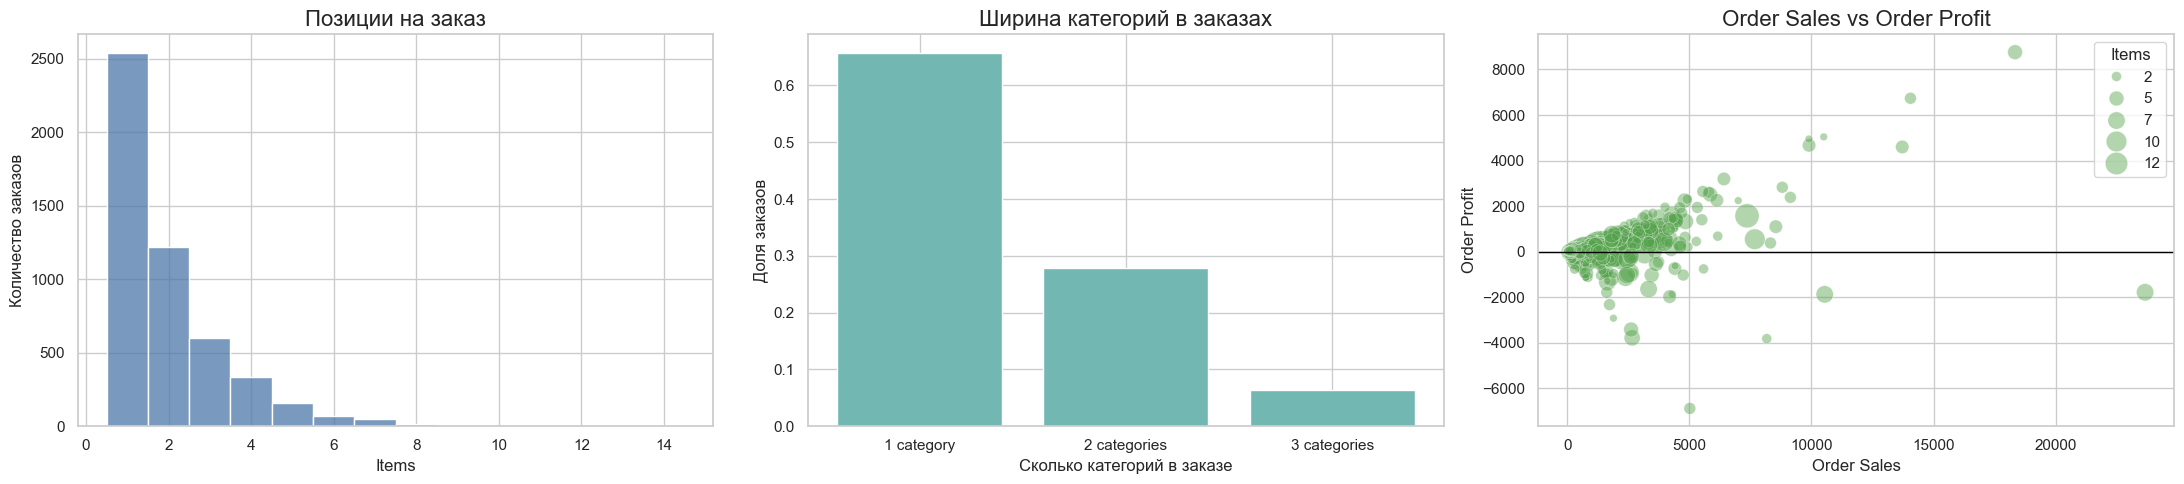


**Уровень заказов**
- Средний заказ включает **2.00** строк, при этом медианный заказ содержит **1** строку.
- Однокатегорийные заказы доминируют (**65.7%**), но мультикатегорийные корзины обеспечивают важный сигнал для cross-sell и анализа прибыльности.
- По scatter видно, что рост размера заказа повышает потенциал прибыли, но одновременно увеличивает разброс результата и риск крупных убыточных заказов.


In [67]:
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    ("Observed", monthly_sales),
    ("Trend", decomposition.trend),
    ("Seasonal", decomposition.seasonal),
    ("Residual", decomposition.resid),
]
for axis, (title, series), color in zip(
    axes,
    components,
    ["#4C78A8", "#72B7B2", "#F58518", "#E45756"],
):
    axis.plot(series.index, series.values, color=color, linewidth=2)
    axis.set_title(title)
plt.tight_layout()
plt.show()

orders = df.groupby("Order ID").agg(
    Order_Sales=("Sales", "sum"),
    Order_Profit=("Profit", "sum"),
    Order_Quantity=("Quantity", "sum"),
    Items=("Row ID", "count"),
    Categories=("Category", "nunique"),
)
category_mix = (
    orders["Categories"]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index={1: "1 category", 2: "2 categories", 3: "3 categories"})
)

display(orders.describe().T.round(2))
display(category_mix.to_frame("share"))

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.histplot(orders["Items"], discrete=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Позиции на заказ")
axes[0].set_xlabel("Items")
axes[0].set_ylabel("Количество заказов")

axes[1].bar(category_mix.index, category_mix.values, color="#72B7B2")
axes[1].set_title("Ширина категорий в заказах")
axes[1].set_xlabel("Сколько категорий в заказе")
axes[1].set_ylabel("Доля заказов")

sns.scatterplot(
    data=orders.reset_index(),
    x="Order_Sales",
    y="Order_Profit",
    size="Items",
    sizes=(30, 300),
    alpha=0.45,
    color="#54A24B",
    ax=axes[2],
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Order Sales vs Order Profit")
axes[2].set_xlabel("Order Sales")
axes[2].set_ylabel("Order Profit")
plt.tight_layout()
plt.show()

print_markdown(
    f'''
**Уровень заказов**
- Средний заказ включает **{orders['Items'].mean():.2f}** строк, при этом медианный заказ содержит **{orders['Items'].median():.0f}** строку.
- Однокатегорийные заказы доминируют (**{percent(category_mix.iloc[0])}**), но мультикатегорийные корзины обеспечивают важный сигнал для cross-sell и анализа прибыльности.
- По scatter видно, что рост размера заказа повышает потенциал прибыли, но одновременно увеличивает разброс результата и риск крупных убыточных заказов.
'''
)


## 5. Анализ скидочной политики и корреляций

Далее в работе будет решаться задача оптимизации продаж и региональной эффективности, поэтому  блок по скидкам критичен: он связывает выручку, прибыльность и управленческие рекомендации.


,Avg_Profit,Loss_Rate,Rows,Avg_Sales
Discount Band,,,,
0%,66.90,0.00,4798,226.74
0-10%,96.06,0.04,94,578.40
10-20%,24.74,0.14,3709,213.58
20-30%,-45.68,0.92,227,454.74
30-50%,-156.28,0.92,310,630.05
50%+,-89.44,1.00,856,75.03


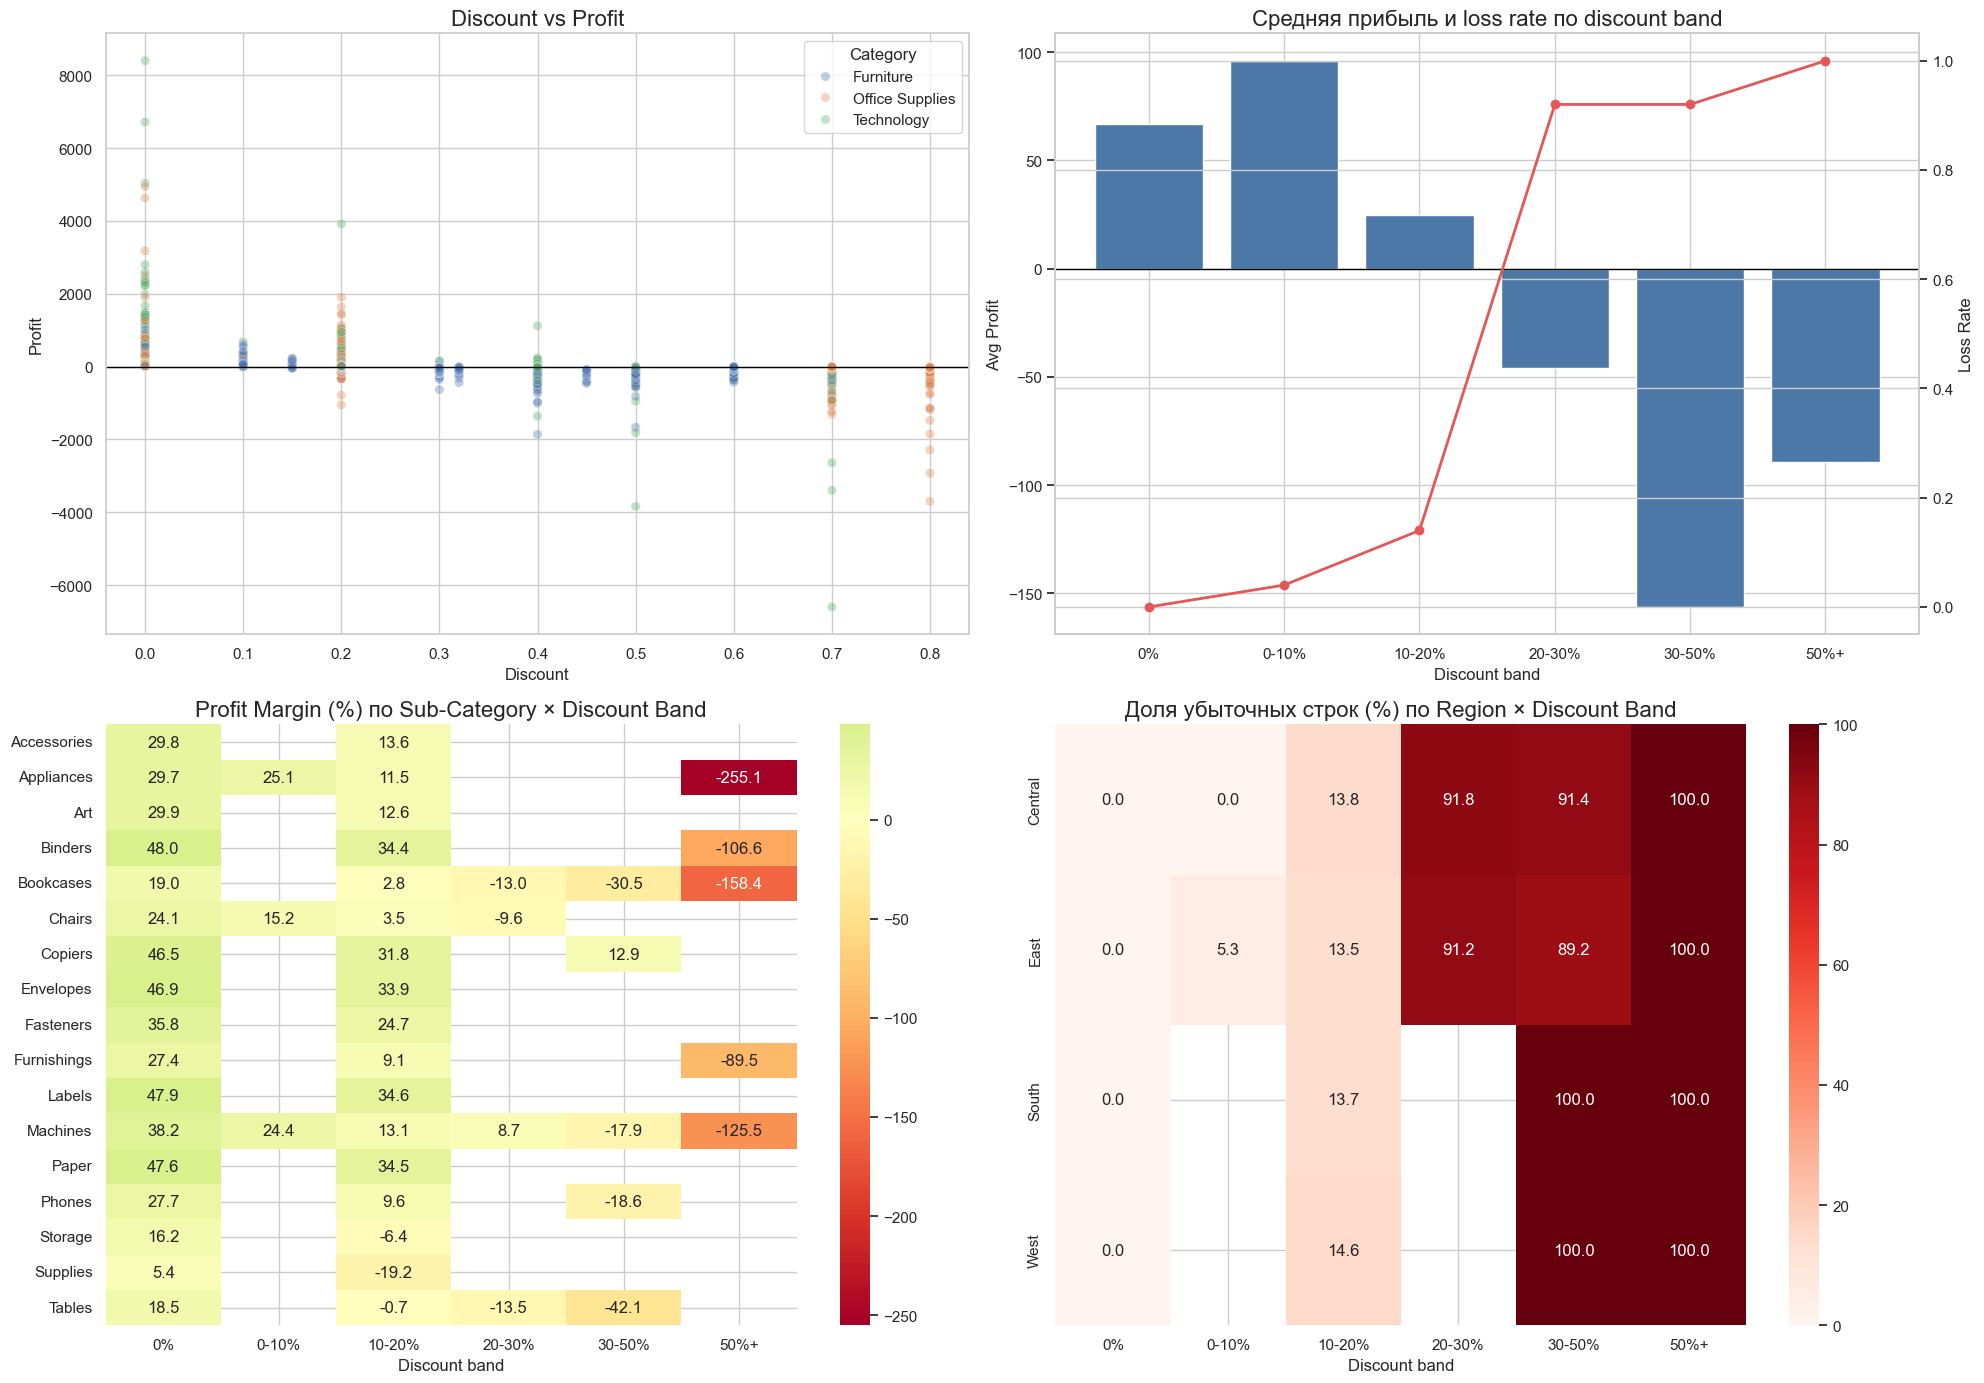


**Что происходит со скидками**
- При `Discount = 0` убыточных строк нет вообще, а средняя прибыль максимальна среди самых массовых корзин.
- После диапазона `20-30%` средняя прибыль становится отрицательной, а доля убыточных строк резко растет.
- Значит, для следующего этапа проекта логично строить не только прогноз продаж, но и рекомендации по скидочным порогам на уровне `Sub-Category × Region`.


In [68]:
discount_summary = (
    df.groupby("Discount Band", observed=False)
    .agg(
        Avg_Profit=("Profit", "mean"),
        Loss_Rate=("Is Loss", "mean"),
        Rows=("Row ID", "count"),
        Avg_Sales=("Sales", "mean"),
    )
    .round(2)
)

subcategory_discount_margin = (
    df.groupby(["Sub-Category", "Discount Band"], observed=False)
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .assign(Profit_Margin=lambda table: 100 * table["Profit"] / table["Sales"])
    .reset_index()
    .pivot(index="Sub-Category", columns="Discount Band", values="Profit_Margin")
)

region_discount_loss = (
    df.groupby(["Region", "Discount Band"], observed=False)["Is Loss"]
    .mean()
    .mul(100)
    .reset_index()
    .pivot(index="Region", columns="Discount Band", values="Is Loss")
)

display(discount_summary)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.35,
    s=45,
    ax=axes[0, 0],
)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Discount vs Profit")
axes[0, 0].set_xlabel("Discount")
axes[0, 0].set_ylabel("Profit")

x_positions = np.arange(len(discount_summary))
axes[0, 1].bar(x_positions, discount_summary["Avg_Profit"], color="#4C78A8")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_xticks(x_positions)
axes[0, 1].set_xticklabels(discount_summary.index)
axes[0, 1].set_title("Средняя прибыль и loss rate по discount band")
axes[0, 1].set_xlabel("Discount band")
axes[0, 1].set_ylabel("Avg Profit")
secondary = axes[0, 1].twinx()
secondary.plot(x_positions, discount_summary["Loss_Rate"], color="#E45756", marker="o", linewidth=2)
secondary.set_ylabel("Loss Rate")

sns.heatmap(subcategory_discount_margin, cmap="RdYlGn", center=0, annot=True, fmt=".1f", ax=axes[1, 0])
axes[1, 0].set_title("Profit Margin (%) по Sub-Category × Discount Band")
axes[1, 0].set_xlabel("Discount band")
axes[1, 0].set_ylabel("")

sns.heatmap(region_discount_loss, cmap="Reds", annot=True, fmt=".1f", ax=axes[1, 1])
axes[1, 1].set_title("Доля убыточных строк (%) по Region × Discount Band")
axes[1, 1].set_xlabel("Discount band")
axes[1, 1].set_ylabel("")
plt.tight_layout()
plt.show()

print_markdown(
    f'''
**Что происходит со скидками**
- При `Discount = 0` убыточных строк нет вообще, а средняя прибыль максимальна среди самых массовых корзин.
- После диапазона `20-30%` средняя прибыль становится отрицательной, а доля убыточных строк резко растет.
- Значит, для следующего этапа проекта логично строить не только прогноз продаж, но и рекомендации по скидочным порогам на уровне `Sub-Category × Region`.
'''
)


,Признак,Spearman vs Profit,Spearman vs Is Loss
2,Discount,-0.54,0.65
0,Sales,0.52,0.01
1,Quantity,0.23,0.00
4,Order Month,0.02,-0.00
3,Delivery Days,-0.01,0.00
5,Order Year,-0.00,-0.00


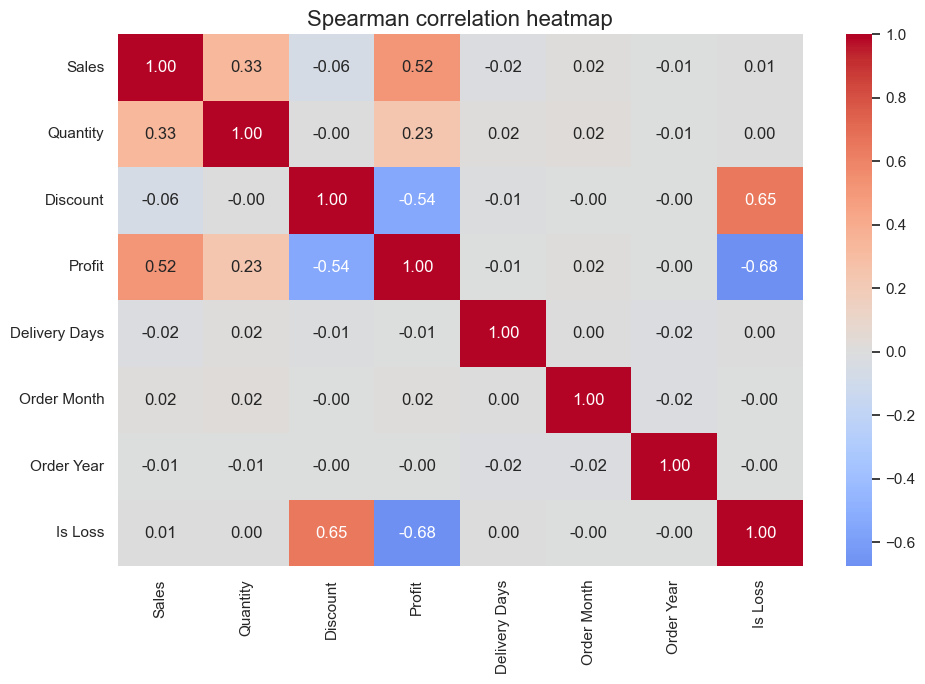

In [70]:
numeric_features = ["Sales", "Quantity", "Discount", "Profit", "Delivery Days", "Order Month", "Order Year", "Is Loss"]
spearman_corr = df[numeric_features].corr(method="spearman")

association_table = pd.DataFrame(
    {
        "Признак": ["Sales", "Quantity", "Discount", "Delivery Days", "Order Month", "Order Year"],
        "Spearman vs Profit": [
            df["Sales"].corr(df["Profit"], method="spearman"),
            df["Quantity"].corr(df["Profit"], method="spearman"),
            df["Discount"].corr(df["Profit"], method="spearman"),
            df["Delivery Days"].corr(df["Profit"], method="spearman"),
            df["Order Month"].corr(df["Profit"], method="spearman"),
            df["Order Year"].corr(df["Profit"], method="spearman"),
        ],
        "Spearman vs Is Loss": [
            df["Sales"].corr(df["Is Loss"], method="spearman"),
            df["Quantity"].corr(df["Is Loss"], method="spearman"),
            df["Discount"].corr(df["Is Loss"], method="spearman"),
            df["Delivery Days"].corr(df["Is Loss"], method="spearman"),
            df["Order Month"].corr(df["Is Loss"], method="spearman"),
            df["Order Year"].corr(df["Is Loss"], method="spearman"),
        ],
    }
).round(3)

display(association_table.sort_values("Spearman vs Profit", key=lambda s: s.abs(), ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()


## Рекомендации по нормализации и feature engineering
- **Sales и Profit имеют длинный правый хвост.** Для линейных моделей использовать `log1p`; для tree-based оставить как есть. Это стабилизирует дисперсию и снизит влияние экстремумов.
- **Postal Code хранится как число.** Оставить строковым идентификатором — у признака нет порядковой семантики.
- **Discount дискретный, но упорядоченный.** Сохранять как ordinal numeric feature. Бинаризация приведёт к потере полезной градации.
- **Месяц для прогнозирования цикличен.** Добавить cyclical encoding: `sin/cos(month)`. Декабрь и январь должны быть близки в признаковом пространстве.
- **Кластеризация клиентов на RFM-признаках.** Применить `StandardScaler` перед K-Means — Recency измеряется в днях и доминирует по масштабу.
- **Customer-region признаки и shipping SLA.** Использовать с осторожностью и явно помечать как synthetic-dependent. В датасете есть артефакты географии и логистики.
- **Сильная зависимость Profit от Discount.** Контролировать leakage и не переоценивать Discount как универсальный драйвер — на реальных данных связь будет менее детерминированной.

## Базовые наборы признаков по задачам
- **Прогнозирование продаж:** lag features, month, quarter, category, sub-category, region, segment, discount history.
- **Региональная аналитика:** region, state, category mix, average discount, profit margin, loss rate.
- **Кластеризация клиентов:** RFM, share of discounted orders, category breadth, average order value.

## Итог EDA

Датасет структурно чистый и пригоден для моделирования, но содержит выраженные артефакты синтетической генерации. Для продаж наблюдаются тренд и сезонность, значит временные признаки и лаги обязательны. Для прибыли и убыточности доминирует скидочный эффект, особенно в сочетании с подкатегорией и регионом. Регион Central действительно выглядит как зона управленческого риска: там ниже прибыль и выше средняя скидка. Для следующего этапа можно переходить к feature engineering и сравнению моделей для прогноза продаж, loss classification и клиентской кластеризации.